# P2

## Importar bibliotecas

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
import numpy as np
import sklearn 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_validate, learning_curve, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# [SUBSTITUÍDO] import tensorflow as tf
# [KERAS removido] # [SUBSTITUÍDO] from tensorflow.keras.models import Sequential
# [KERAS removido] # [SUBSTITUÍDO] from tensorflow.keras.layers import Dense, Dropout, Input
# [KERAS removido] # [SUBSTITUÍDO] from tensorflow.keras.regularizers import l2
# [KERAS removido] # [SUBSTITUÍDO] from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
# --- Classificação ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold


# --- Redes Neuronais via sklearn (substitui Keras/TF) ---
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.pipeline import Pipeline


**Análise:** Importam-se todas as bibliotecas necessárias (pandas, numpy, matplotlib/seaborn
para visualização, scikit-learn para pré-processamento, regressão, classificação,
redes neuronais (`MLPRegressor`/`MLPClassifier`) e validação cruzada, e `scipy.stats`
para os testes estatísticos). Não há resultados a comentar nesta célula — serve apenas
de preparação do ambiente. *Para o artigo:* pode ser referido brevemente na secção de
Metodologia que toda a análise foi feita em Python com scikit-learn.


#### Definir style sheet

In [2]:
# 1. Apply base seaborn-paper style
plt.style.use('seaborn-v0_8-paper')  # Use 'seaborn-paper' if on older matplotlib versions

# 2. Overhaul rcParams for maximum article readability
plt.rcParams.update({
    # Text and Typography
    "text.usetex": False,                   # Set to True ONLY if you have a local LaTeX installation
    
    # Font Sizes (Optimized for standard paper columns)
    "axes.labelsize": 10,                   # X and Y axis titles
    "axes.titlesize": 11,                   # Plot title
    "xtick.labelsize": 8,                   # X-axis tick labels
    "ytick.labelsize": 8,                   # Y-axis tick labels
    "legend.fontsize": 8,                   # Legend items font size
    "legend.title_fontsize": 9,             # Legend title font size
    
    # Figure Layout & Dimensions
    "figure.figsize": [3.39, 2.5],          # Fits standard 3.39-inch single columns (e.g., IEEE/Nature)
    "figure.constrained_layout.use": True,  # Auto-adjusts padding to prevent clipped text
    "figure.dpi": 150,                      # Crisp display rendering on high-res monitors
    
    # Plot Styling details
    "axes.spines.top": False,               # Strip away top bounding box border
    "axes.spines.right": False,             # Strip away right bounding box border
    "axes.grid": True,                      # Keep grids enabled for data alignment
    "grid.alpha": 0.3,                      # Make grid lines subtle and unobtrusive
    "grid.linestyle": "--",                 # Dashed grid lines
    "lines.linewidth": 1.25,                # Slightly thicker lines for visibility
    "lines.markersize": 4,                  # Balanced data marker dots
    
    # Vector Graphics Export Stability
    "pdf.fonttype": 42,                     # Embed true fonts inside PDFs (prevents text errors)
    "ps.fonttype": 42                       # Embed true fonts inside PostScript formats
})

pd.set_option('display.max_columns', 50)  # Remove o limite de colunas
pd.set_option('display.max_rows', 100)     # Remove o limite de linhas
pd.set_option('display.width', 300)        # Evita que o texto quebre para a linha de baixo


**Análise:** Define-se o estilo gráfico global (estilo "paper", tamanhos de fonte,
grelhas, layout) para que todas as figuras geradas ao longo do notebook tenham uma
aparência consistente e adequada a um artigo científico (estilo IEEE — figuras
pequenas, legíveis em duas colunas). Também se ajustam as opções de visualização do
pandas para mostrar mais colunas/linhas sem truncar. Não produz resultados analíticos;
é apenas configuração.


## EDA e Pré Processamento
### Carregar Dataframe

In [3]:
DATASET_FILE_PATH = "PTD_level_dataset.xlsx"
df = pd.read_excel(DATASET_FILE_PATH)
df.head()


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,64.08,3.522977,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,-13.20,3.522977,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,173.10,3.522977,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30



**Análise:** Carrega-se o ficheiro `PTD_level_dataset.xlsx` (resultado da junção de
`IP_data.xlsx` e `PTD_data.xlsx`) e mostra-se um preview (`head()`) com as primeiras
5 linhas. *Para o artigo (secção "Dados"):* refira a origem do dataset, o número de
variáveis (32 colunas) e a unidade de análise — um registo por PTD (Posto de
Transformação de Distribuição).


| # | Propriedade | Tipo | Descrição |
|---|---|---|---|
| 1 | Distrito | Categórica | Distrito português onde o PTD está localizado |
| 2 | Concelho | Categórica | Concelho associado ao PTD |
| 3 | CodDistritoConcelho | Identificador | Código único que representa a combinação distrito + concelho |
| 4 | Código de Instalação | Identificador | Identificador único do Posto de Transformação |
| 5 | Coordenadas Geográficas | Geográfica | Latitude e longitude do PTD |
| 6 | Potência instalada [kVA] | Numérica | Potência nominal instalada no PTD |
| 7 | Tipo Construtivo | Categórica | Tipo físico/construtivo do PTD |
| 8 | Cap_PTD_kVA | Numérica | Capacidade total do PTD em kVA |
| 9 | Pot_Contratada_kVA | Numérica | Soma da potência contratada pelos clientes ligados ao PTD |
| 10 | N_Clientes | Inteira | Número total de clientes associados ao PTD |
| 11 | Pot_Geracao_kW | Numérica | Potência de geração local (produção elétrica distribuída) |
| 12 | N_Clientes_Produtores | Inteira | Número de clientes produtores de energia |
| 13 | P_IP_Total | Numérica | Potência total consumida pela iluminação pública |
| 14 | P_IP_Inef | Numérica | Potência associada à iluminação pública ineficiente |
| 15 | Rate_Ineficiencia | Numérica | Taxa de ineficiência energética da iluminação pública |
| 16 | LED_Ratio | Numérica | Percentagem/proporção de luminárias LED |
| 17 | N_Luminarias | Inteira | Número total de luminárias |
| 18 | N_Lampadas | Inteira | Número total de lâmpadas |
| 19 | N_PTDs_Concelho | Inteira | Número de PTD existentes no concelho |
| 20 | PVE_PTD | Numérica | Potência estimada necessária para veículos elétricos |
| 21 | D_PTD | Numérica | Saldo de viabilidade energética do PTD |
| 22 | IP_per_PTD | Numérica | Média da potência de iluminação pública por PTD |
| 23 | IP_Inef_per_PTD | Numérica | Média da potência ineficiente por PTD |
| 24 | Ganho_LED_PTD | Numérica | Ganho energético obtido pela substituição por LED |
| 25 | D_PTD_LED | Numérica | Saldo energético do PTD após modernização LED |
| 26 | Cap_per_Cliente | Numérica | Capacidade média disponível por cliente |
| 27 | PContratada_per_Cliente | Numérica | Potência contratada média por cliente |
| 28 | Geracao_per_Cliente | Numérica | Geração média de energia por cliente |
| 29 | Clientes_Produtores_Ratio | Numérica | Percentagem/proporção de clientes produtores |
| 30 | Nível de Utilização [%] | Numérica | Percentagem de utilização da capacidade do PTD |
| 31 | Util_Decimal | Numérica | Representação decimal do nível de utilização |
| 32 | PFolga_PTD | Numérica (Target) | Capacidade livre/remanescente do PTD para novas cargas elétricas |

In [4]:
# Primeira limpeza
df.drop_duplicates(inplace= True)


**Análise:** Remoção de eventuais linhas duplicadas (`drop_duplicates`). Esta é uma
etapa de limpeza básica antes de qualquer análise — garante que cada PTD é contado
apenas uma vez. [PREENCHER]: indicar quantas linhas (se alguma) foram removidas,
comparando `df.shape` antes/depois.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  str    
 1   Concelho                   72027 non-null  str    
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  str    
 4   Coordenadas Geográficas    72027 non-null  str    
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  str    
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  72027 non-null  float64
 14  R


**Análise:** `df.info()` mostra o resumo da estrutura do dataset: 72 027 registos e
32 colunas, com tipos `int64`, `float64`, `category`/`str`. Confirma-se a presença de
valores omissos em várias colunas — nomeadamente `Pot_Contratada_kVA` (~50 847 não
nulos, ou seja ~30% de nulos), `Pot_Geracao_kW` e `Geracao_per_Cliente` (apenas 1 836
não nulos, i.e. ~97% de nulos), e `D_PTD`/`D_PTD_LED`/`Util_Decimal`/`PFolga_PTD`
(68 963 não nulos). *Para o artigo (secção EDA):* esta informação justifica
diretamente as decisões de tratamento de nulos tomadas mais à frente (imputação por
zero para variáveis de geração, imputação pela mediana para `Pot_Contratada_kVA`, e
remoção de linhas para as variáveis-chave com ~4.2% de nulos).


In [6]:
df["CodDistritoConcelho"] = df["CodDistritoConcelho"].astype(str).astype('category')


**Análise:** Converte-se `CodDistritoConcelho` para `category` (via `str`), uma vez
que é um código identificador (chave de junção entre IP e PTD), não uma quantidade —
não deve ser tratado como número em modelos de regressão/classificação. Não produz
output visual, mas é importante para evitar que esta variável seja indevidamente
incluída como feature numérica nos modelos (deve ser excluída ou tratada como
categórica/ID).


### Resumo
- Tamanho: ~72.000 registos; mix de variáveis categóricas, inteiras e decimais.

- Nulos: Pot_Contratada_kVA, Pot_Geracao_kW, D_PTD, D_PTD_LED, Geracao_per_Cliente,Util_Decimal, PFolga_PTD; 

- Dependências: variáveis derivadas dependem de outras (PContratada_per_Cliente ← Pot_Contratada_kVA, Geracao_per_Cliente ← Pot_Geracao_kW).

- Oportunidades: analisar potência por território, concentração de clientes, ineficiência e diferenças LED/distritos.

- CodDistritoConcelho tem de ser categorico

### Primeiros Passos

- Tratar nulos: avaliar caso a caso (imputar / manter / remover).
- Verificar derivadas: confirmar fórmulas e origem dos campos calculados.
- Converter campos: percentagens → numérico; coordenadas → lat/lon.
- Análises: agregações por concelho/distrito, mapas e modelos simples se for preciso.

### Variáveis categóricas

In [7]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Columns: \n",  categorical_columns)

Categorical Columns: 
 ['Distrito', 'Concelho', 'CodDistritoConcelho', 'Código de Instalação', 'Coordenadas Geográficas', 'Tipo Construtivo', 'Nível de Utilização [%]']


/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/1750260199.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()



**Análise:** Lista as colunas categóricas/texto identificadas: `Distrito`, `Concelho`,
`CodDistritoConcelho`, `Código de Instalação`, `Coordenadas Geográficas`,
`Tipo Construtivo`, `Nível de Utilização [%]`. *Para o artigo:* pode listar-se esta
tabela como ponto de partida da secção de pré-processamento de variáveis categóricas.


In [8]:
# Unique values for each categorical column
print("Valores únicos de variáveis categóricas")
for column in categorical_columns:
    unique_vals = df[column].unique()
    
    print(f"\n\n{column} ({len(unique_vals)} valores únicos):\n {unique_vals}")

Valores únicos de variáveis categóricas


Distrito (18 valores únicos):
 <StringArray>
['Porto', 'Santarém', 'Setúbal', 'Lisboa', 'Portalegre', 'Aveiro', 'Viseu', 'Beja', 'Braga', 'Bragança', 'Castelo Branco', 'Coimbra', 'Évora', 'Faro', 'Guarda', 'Leiria', 'Viana do Castelo', 'Vila Real']
Length: 18, dtype: str


Concelho (278 valores únicos):
 <StringArray>
['Marco de Canaveses',         'Matosinhos',  'Paços de Ferreira',            'Paredes',           'Penafiel',              'Porto',    'Póvoa de Varzim',        'Santo Tirso',            'Valongo',      'Vila do Conde',
 ...
              'Viseu',             'Nazaré',           'Barreiro',           'Grândola',              'Moita',            'Montijo',            'Palmela',  'Santiago do Cacém',             'Seixal',           'Sesimbra']
Length: 278, dtype: str


CodDistritoConcelho (278 valores únicos):
 ['1307', '1308', '1309', '1310', '1311', ..., '1507', '1508', '1509', '1510', '1511']
Length: 278
Categories (278, str): [


**Análise:** Mostra os valores únicos de cada variável categórica. Permite identificar:
(i) `Distrito`/`Concelho` — muitas categorias (geografia), candidatas a agregação ou
remoção em modelos (alta cardinalidade); (ii) `Código de Instalação` — identificador
único por PTD, deve ser usado como índice e não como feature; (iii)
`Coordenadas Geográficas` — string "lat,lon" que precisa de *parsing*; (iv)
`Tipo Construtivo` — poucas categorias, boa candidata a One-Hot Encoding;
(v) `Nível de Utilização [%]` — variável ordinal com possíveis valores "N/D" que
precisam de tratamento. *Para o artigo:* esta exploração justifica as transformações
da célula seguinte (criação de `latitude`/`longitude`, definição do índice, e a
decisão de manter "N/D" como classe própria em `Nível de Utilização [%]`).


- Tipos textuais **Único**: Código de Instalação (ID) pode ser utilizado como index; 
- Tipos textuais: Coordenadas Geográficas precisa de parsing (lat/lon); 
- Nível de Utilização [%] tem “%” N/D e tem de ser tratado.

In [9]:
# Set index
df.set_index("Código de Instalação", inplace=True)


**Análise:** Define-se `Código de Instalação` como índice do DataFrame — é um
identificador único por PTD e não deve entrar como variável explicativa nos modelos
(evita "data leakage" por ID e simplifica a referência a cada registo).


In [10]:
# Split Coordenadas
df[["latitude", "longitude"]] = df["Coordenadas Geográficas"].str.split(",", expand=True)
df.drop(columns="Coordenadas Geográficas", inplace=True)

# Converter em float
df["latitude"] = df["latitude"].astype(float)
df["longitude"] = df["longitude"].astype(float)
df.head()

,Distrito,Concelho,CodDistritoConcelho,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD,latitude,longitude
Código de Instalação,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1307D2012500,Porto,Marco de Canaveses,1307,400,Cabine pré-fabricada,400,105269.0,131,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,64.08,3.522977,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28,41.184901,-8.147853
1307D2012900,Porto,Marco de Canaveses,1307,250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30,41.086993,-8.246734
1307D2013100,Porto,Marco de Canaveses,1307,250,Cabine alta,250,110419.0,176,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30,41.112922,-8.212765
1307D2013800,Porto,Marco de Canaveses,1307,50,Aéreo - AS,50,23807.0,36,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,-13.20,3.522977,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00,41.132953,-8.135634
1307D2015100,Porto,Marco de Canaveses,1307,250,Aéreo - AI,250,60851.0,94,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,173.10,3.522977,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30,41.122844,-8.112901



**Análise:** A coluna `Coordenadas Geográficas` (string "lat,lon") é separada em duas
novas colunas numéricas, `latitude` e `longitude`, e a coluna original é eliminada.
Estas coordenadas serão usadas na visualização geográfica (mapa de densidade) mas
não devem ser usadas diretamente como variáveis explicativas nos modelos preditivos
(são apenas localização, não causa direta da folga de rede — podem ser discutidas
como possível extensão/limitação no artigo, ex.: efeitos regionais).


/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/3953044636.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


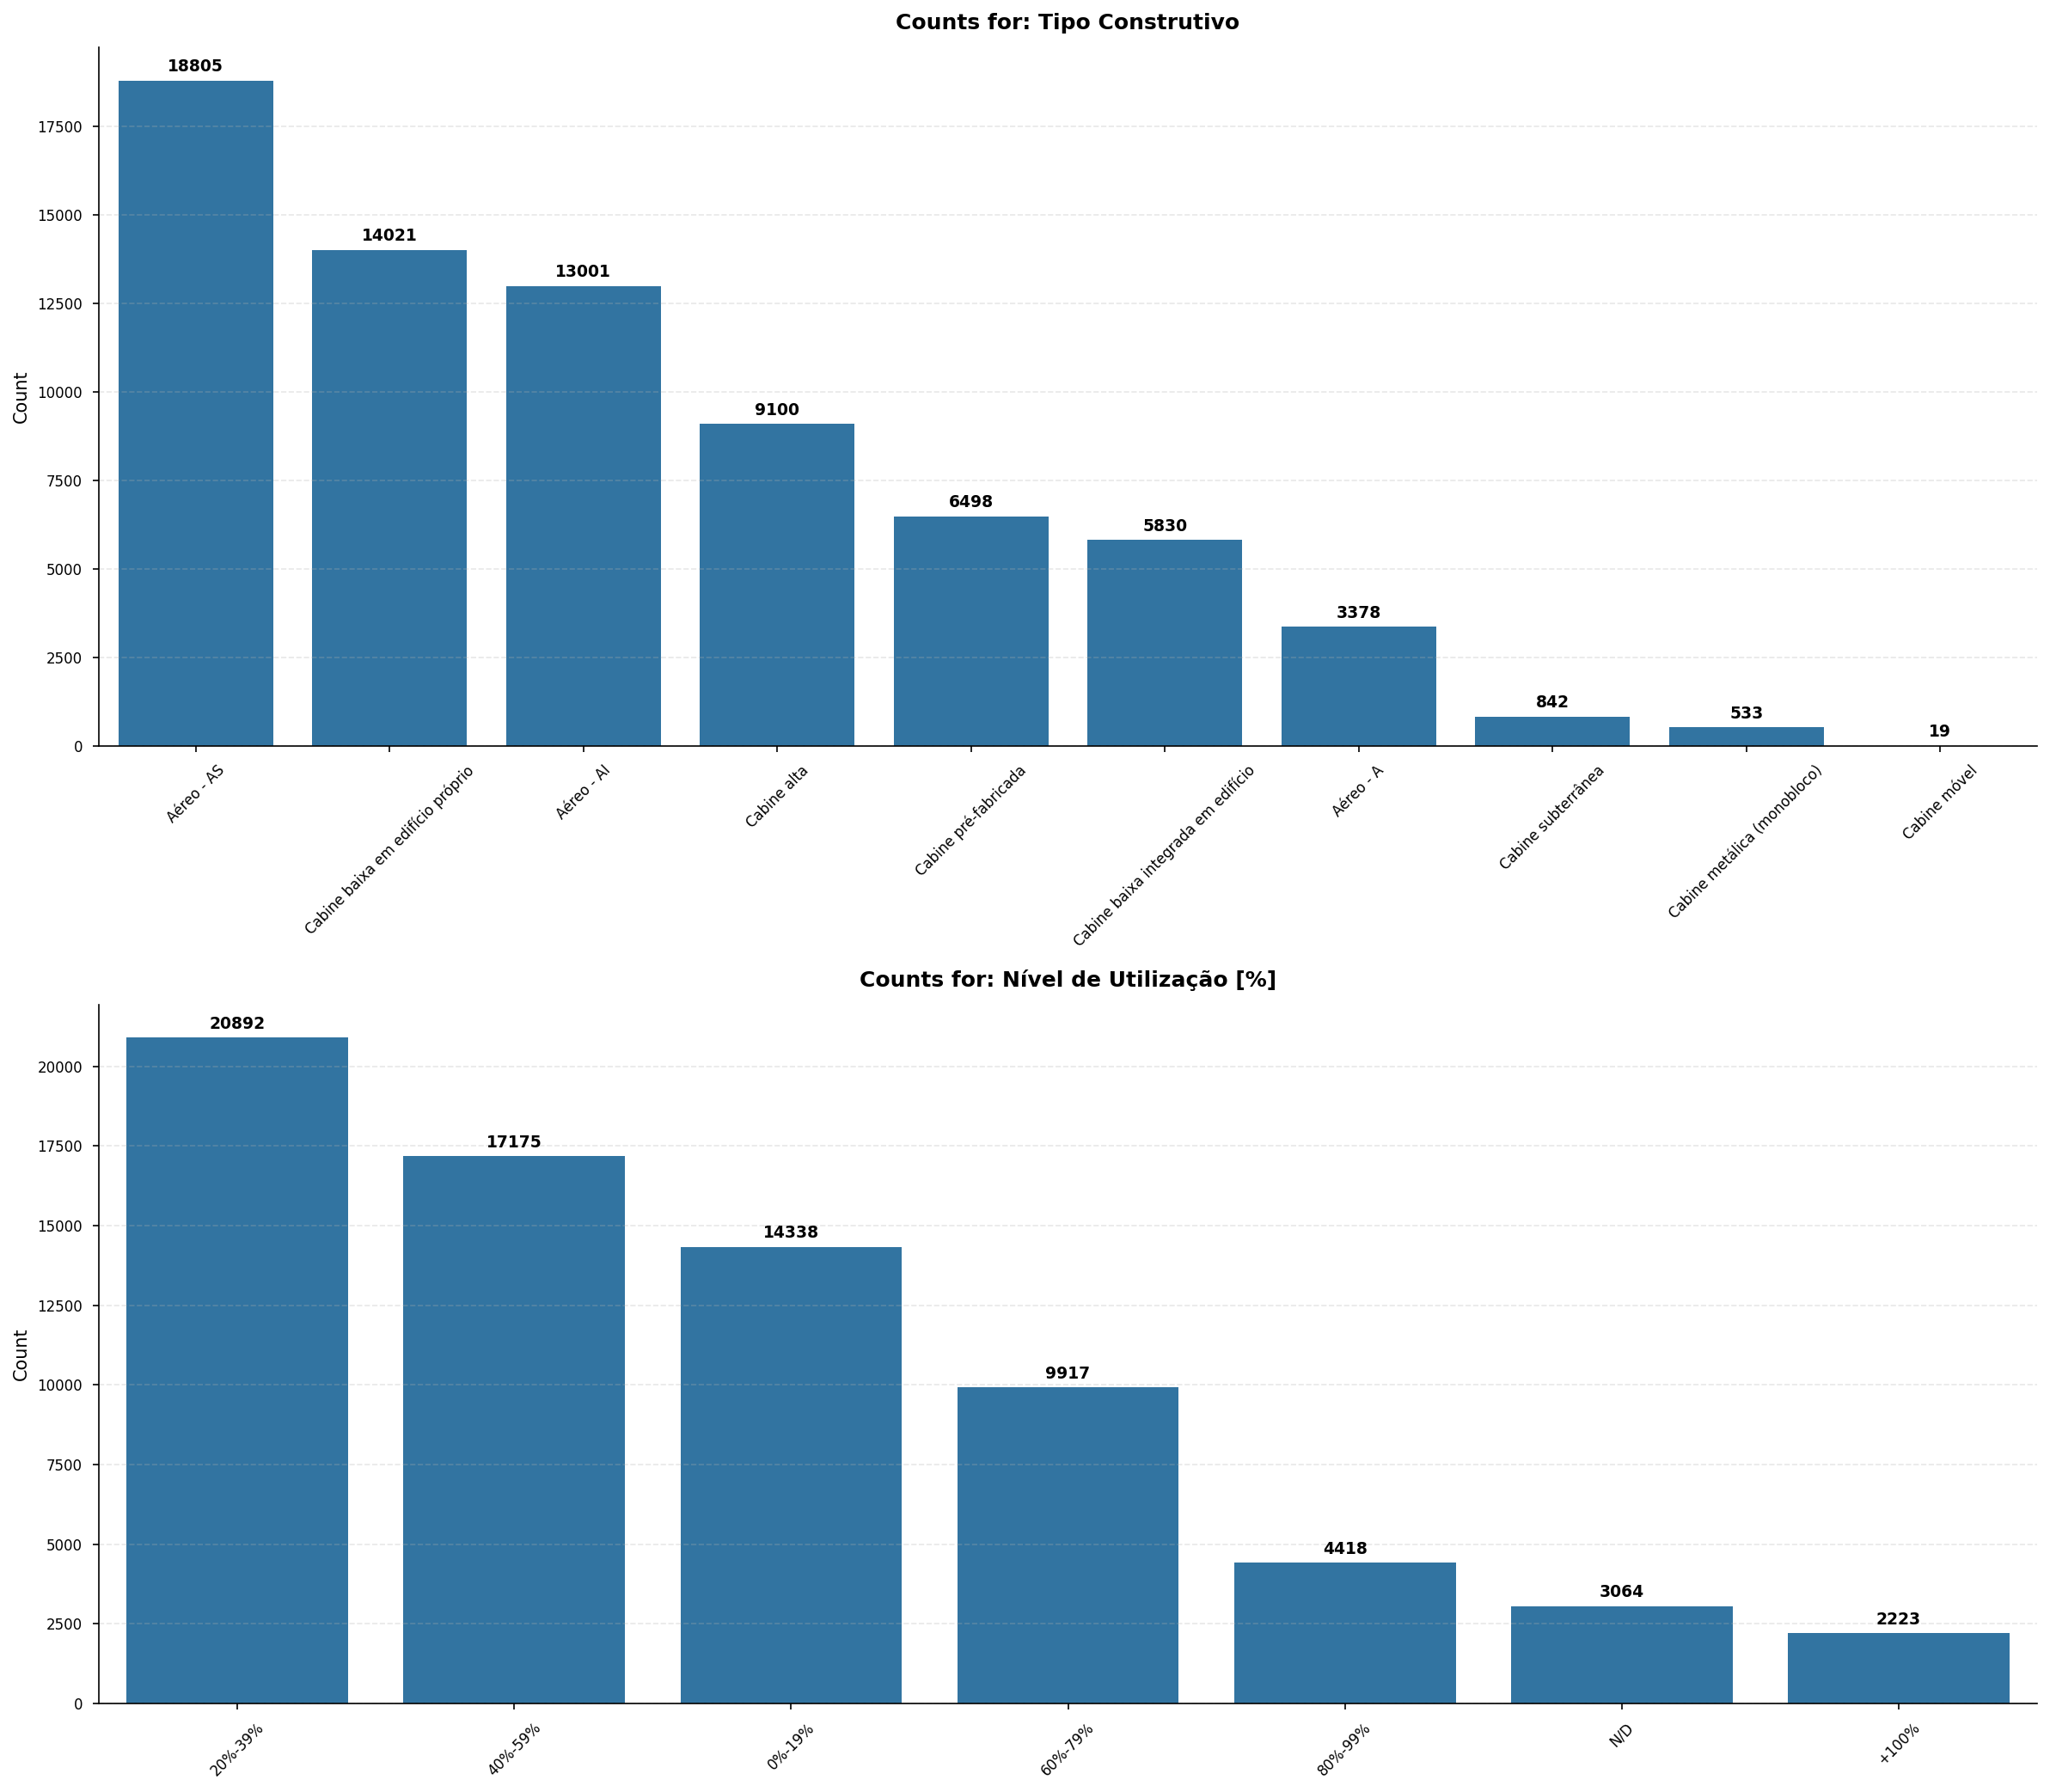

In [11]:
# 1. Filter out columns with > 20 unique values up front
categorical_columns = [
    col
    for col in df.select_dtypes(include=["object", "category", "string"]).columns
    if df[col].nunique() <= 10
]

# 2. Dynamic grid layout calculation
num_cols = len(categorical_columns)
grid_cols = 1  # Adjust this to 3 or 4 if you have many columns
grid_rows = math.ceil(num_cols / grid_cols)

# 3. Create the single figure context
fig, axes = plt.subplots(
    grid_rows, grid_cols, figsize=(16, 14)
)
axes = axes.flatten()  # Flatten to easily loop over them with a single index

# 4. Populate the subplots
for i, column in enumerate(categorical_columns):
    ax = axes[i]

    # Create the sorted count plot on the specific subplot axis (ax=ax)
    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index,
        legend=False,
        ax=ax,
    )

    # Loop through all containers to label every single bar
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9, weight="bold")

    # Clean up labels per subplot
    ax.set_title(f"Counts for: {column}", fontsize=12, pad=10, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)


# 5. Hide any leftover/empty subplot boxes in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing and display
plt.tight_layout()
plt.show()


**Análise:** Geram-se gráficos de contagem (`countplot`) para as variáveis
categóricas com baixa cardinalidade (≤10 valores únicos), com o número de ocorrências
anotado em cada barra. [PREENCHER]: descrever a distribuição observada — por exemplo,
se `Tipo Construtivo` está dominado por um ou dois tipos, e se `Nível de Utilização
[%]`/"N/D" representa uma fração relevante dos registos. *Para o artigo:* esta figura
pode ilustrar o desequilíbrio de classes nas variáveis categóricas, relevante para
justificar decisões de codificação (One-Hot Encoding) e para a discussão de
limitações dos dados.


Como N/D é uma classe significativa é melhor considera-la para um modelo final.

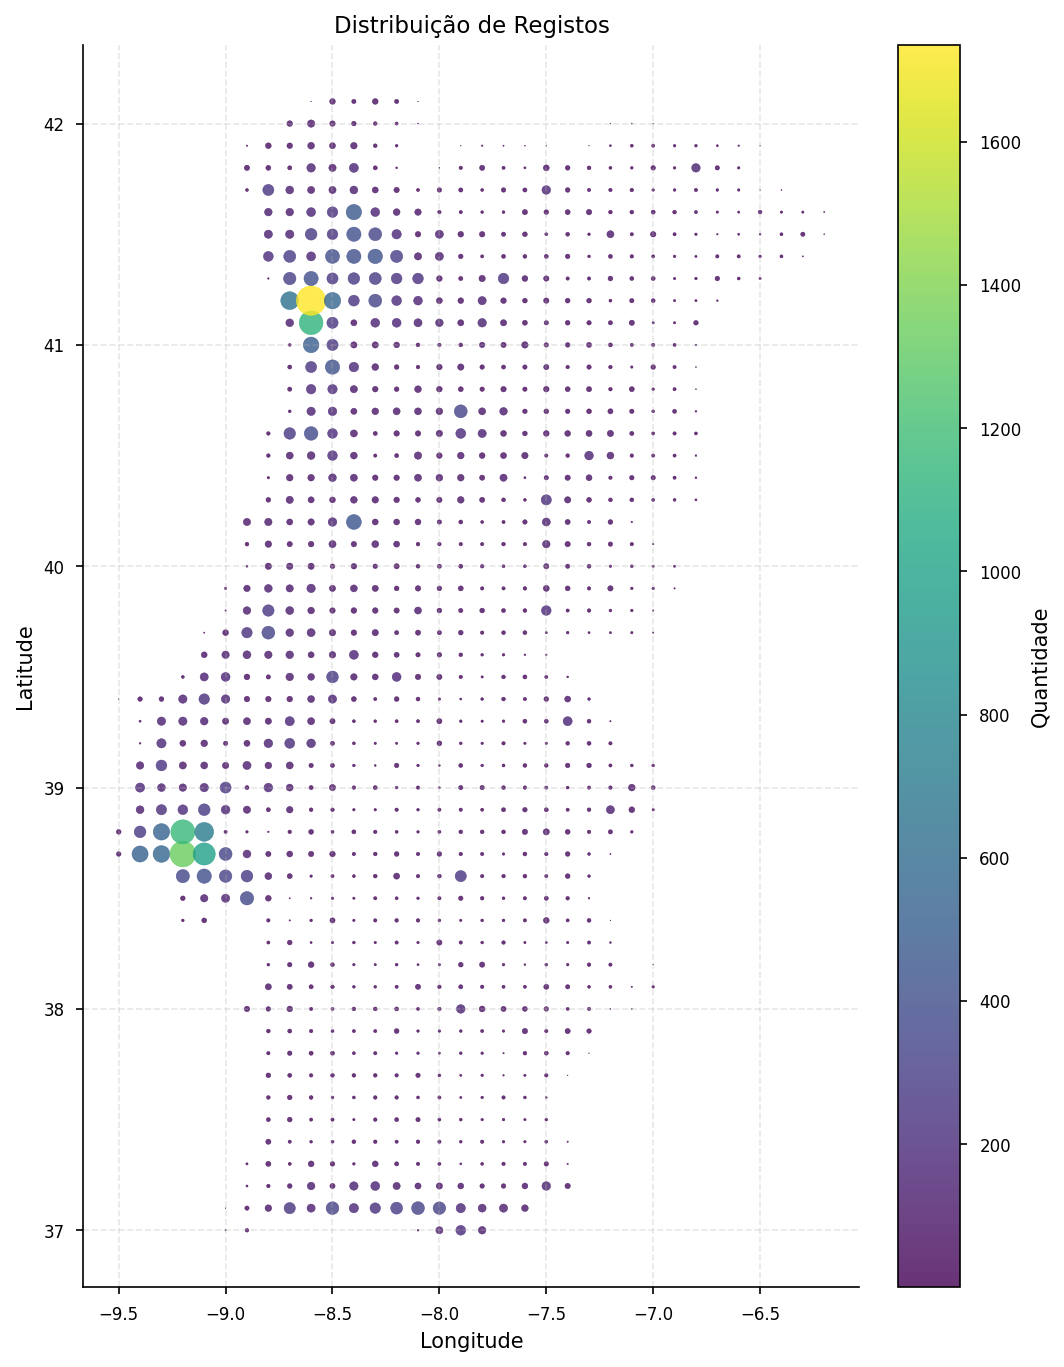

In [12]:
df_mapa = (
    df.assign(
        lat_round=df["latitude"].round(1),
        lon_round=df["longitude"].round(1)
    )
    .groupby(["lat_round", "lon_round"])
    .size()
    .reset_index(name="quantidade")
)

plt.figure(figsize=(7, 9))

# Plot standard points where color and size reflect "quantidade"
sc = plt.scatter(
    df_mapa["lon_round"], 
    df_mapa["lat_round"], 
    c=df_mapa["quantidade"], 
    cmap="viridis",
    s=df_mapa["quantidade"] / df_mapa["quantidade"].max() * 200, # Variable sizing
    alpha=0.8
)

plt.colorbar(sc, label="Quantidade")
plt.title("Distribuição de Registos")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


**Análise:** Constrói-se um mapa de densidade dos PTDs (agregando por
latitude/longitude arredondadas a 1 decimal), onde a cor e o tamanho dos pontos
refletem o número de registos nessa célula geográfica. Confirma-se a forte
concentração de PTDs ao longo do litoral português, com focos mais intensos nas
áreas metropolitanas de Lisboa e Porto, e menor densidade no interior. *Para o
artigo (secção EDA — contexto geográfico):* esta figura é útil para discutir o
desequilíbrio geográfico da amostra — uma limitação a referir na secção de
Conclusões/Limitações, já que os modelos serão influenciados predominantemente pelos
padrões litorais.


Ao olhar para este mapa de densidade, a primeira coisa que salta à vista é a forte concentração dos  dados ao longo de toda a faixa litoral de Portugal Continental.

Destacam-se claramente dois grandes "focos" a amarelo (onde há maior volume de registos): um na região da Grande Lisboa e outro na zona do Grande Porto.

Em contrapartida, nota-se perfeitamente que a zona interior do país está muito mais "vazia", com pontos de densidade muito mais baixos espalhados pelo território. No fundo, a distribuição no mapa acompanha, de forma muito clara, as zonas de maior e menor densidade populacional do país.

### Variáveis Numéricas


In [13]:
df.describe()

,Potência instalada [kVA],Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Util_Decimal,PFolga_PTD,latitude,longitude
count,72027.000000,72027.000000,50847.000000,72027.000000,1836.000000,72027.000000,72027.000000,72027.000000,72027.000000,72027.000000,72027.000000,72027.000000,72027.000000,7.202700e+04,68963.000000,72027.000000,72027.000000,72027.000000,68963.000000,72027.000000,50847.000000,1836.000000,72027.000000,68963.000000,68963.000000,72027.000000,72027.000000
mean,302.798825,302.798825,80941.484060,94.698002,6216.724401,20.203479,1381.490215,463.290614,0.280694,0.671746,21800.367904,21832.557235,484.294376,1.320000e+01,134.783315,2.506114,0.856743,0.556883,135.343310,5.752241,711.591520,36.666427,0.508043,0.513849,147.983315,39.865313,-8.361586
std,294.444527,294.444527,67146.029444,110.055146,2876.377899,2.017686,1723.710579,708.009567,0.240367,0.273099,17634.684356,17715.517084,431.611257,1.776369e-15,186.759871,1.083828,1.057501,0.687375,186.850323,8.513091,317.283001,26.495930,0.372627,0.246994,186.759871,1.358247,0.604654
min,0.000000,0.000000,5456.000000,20.000000,1622.000000,20.000000,23.218600,0.000000,0.000000,0.011698,589.000000,589.000000,19.000000,1.320000e+01,-13.200000,0.473284,0.000000,0.000000,-13.200000,0.000000,222.812500,3.222749,0.013908,0.190000,0.000000,36.974589,-9.505183
25%,100.000000,100.000000,34035.500000,20.000000,4271.750000,20.000000,382.569000,28.985000,0.064209,0.500703,8867.000000,8844.000000,194.000000,1.320000e+01,24.060000,1.817698,0.105130,0.068334,24.160309,1.923077,545.682423,20.220713,0.163934,0.390000,37.260000,38.767525,-8.751868
50%,250.000000,250.000000,60886.000000,54.000000,5574.500000,20.000000,842.179701,137.720000,0.229231,0.719614,17175.000000,17103.000000,377.000000,1.320000e+01,64.080000,2.298665,0.490339,0.318720,64.377532,2.906977,643.139785,29.957789,0.370370,0.390000,77.280000,39.969036,-8.467938
75%,400.000000,400.000000,106720.000000,124.000000,7393.500000,20.000000,1766.391301,625.790000,0.447381,0.911563,29747.000000,29771.000000,610.000000,1.320000e+01,211.280000,2.911925,1.172828,0.762338,211.348334,5.102041,770.474599,44.394482,1.000000,0.590000,224.480000,41.151804,-7.966075
max,8000.000000,8000.000000,804687.000000,1438.000000,22032.000000,106.000000,9065.655300,3494.920000,0.983568,1.000000,86026.000000,86712.000000,2278.000000,1.320000e+01,4476.400000,6.338273,5.395278,3.506931,4479.225328,283.500000,8820.000000,355.377778,1.000000,1.000000,4489.600000,42.149844,-6.214944



**Análise:** `df.describe()` apresenta as estatísticas descritivas (média, desvio
padrão, mínimo, máximo, quartis) de todas as variáveis numéricas. [PREENCHER]:
destacar na tabela do artigo as variáveis com maior dispersão (desvio padrão elevado
relativamente à média) e eventuais valores mínimos/máximos que sugiram outliers
(ex.: capacidades muito acima da média em PTDs de grandes centros urbanos). Esta
tabela serve de base à discussão de outliers feita mais à frente (winsorization).


#### 1. Dimensão e Dados em Falta (Missing Values)

O dataset contém uma base de 72.027 registos analisados na maioria das colunas.
Há um grande número de nulos nas variáveis de geração de energia (Pot_Geracao_kW e Geracao_per_Cliente), que possuem apenas 1.836 registos. Isto indica que uma pequena minoria (~2.5%) dos postos/instalações tem registo de produção ativa (como painéis solares na área).
A coluna de Pot_Contratada_kVA também apresenta falhas, com apenas 50.847 registos válidos (cerca de 30% da base sem dados desta variável). Outras variáveis descritivas (como D_PTD, Util_Decimal) também têm cerca de 3.000 registos em falta.

#### 2. Assimetria (Outliers Severos / Right-Skewed)

Existe uma variabilidade extrema em variáveis-chave. Por exemplo:
N_Clientes: A mediana é 54, a média é 94, mas o máximo atinge valores absurdos de 1.438 clientes num só posto.
Potência instalada [kVA]: A maioria ronda os 250 kVA (mediana), mas há postos massivos com capacidades até 8.000 kVA. Isto sugere que há um pequeno grupo de PTDs (Postos de Transformação de Distribuição) altamente densos (zonas super urbanas/industriais) perante uma vasta maioria mais "leve" ou rural.

#### 3. Penetração LED vs Ineficiência

Adoção LED avançada: O LED_Ratio médio é de cerca de 67%, com a mediana em quase 72% e o percentil 75 já acima dos 91%. Isto demonstra que a atualização da rede de iluminação para LED não só já começou, como está fortemente instalada.
Margem para melhoria (Ineficiência): Apesar de bons níveis de LED, o Rate_Ineficiencia situa-se nos 28% (média), chegando os casos extremos perto dos 98%. Há, portanto, oportunidades claras de melhoria (por exemplo, ao reduzir P_IP_Inef).

#### 4. Capacidade e Utilização

A taxa de utilização média (Util_Decimal) está em torno de 51% (com metade a operar abaixo dos 39%).
Isto alinha-se perfeitamente com a variável PFolga_PTD (Folga real do PTD), indicando que, na generalidade, a rede de distribuição parece ter boas "gorduras" para evitar sobrecargas extremas.

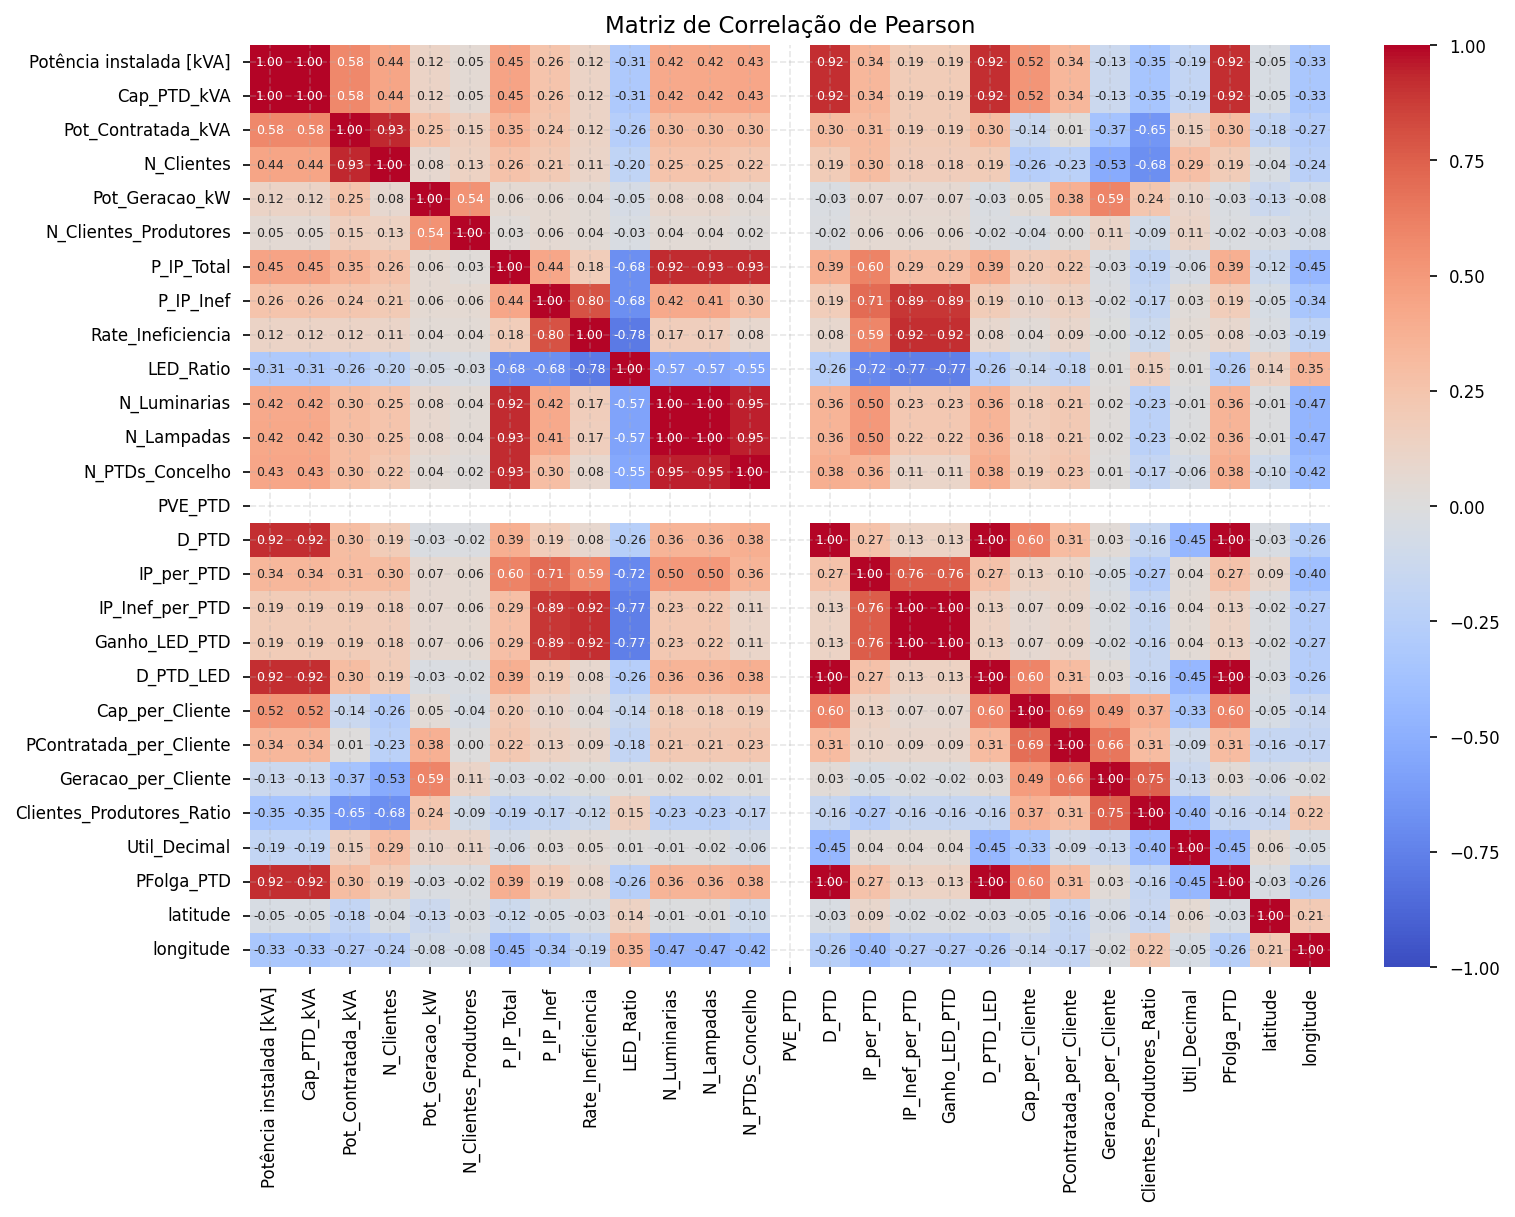

In [14]:
corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,
    annot_kws={"size": 6}, # Adjusted annotation size
    cmap='coolwarm',    
    fmt=".2f",           
    vmin=-1, vmax=1      
)

plt.title('Matriz de Correlação de Pearson')
plt.show()


**Análise:** Mostra-se a matriz de correlação de Pearson entre todas as variáveis
numéricas, como heatmap. [PREENCHER]: identificar pares de variáveis fortemente
correlacionadas (|r| > 0.8–0.9), em particular variáveis "derivadas" que sejam quase
combinações lineares de outras (ex.: `Cap_per_Cliente` vs `Cap_PTD_kVA`/`N_Clientes`,
ou `D_PTD`/`D_PTD_LED` vs `PFolga_PTD`). *Para o artigo (secção EDA):* esta figura
fundamenta diretamente a remoção de variáveis altamente correlacionadas com o alvo
feita mais à frente (limiar 0.95), evitando *data leakage* nos modelos de regressão.


/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/2492322895.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar layout para não sobrepor o título


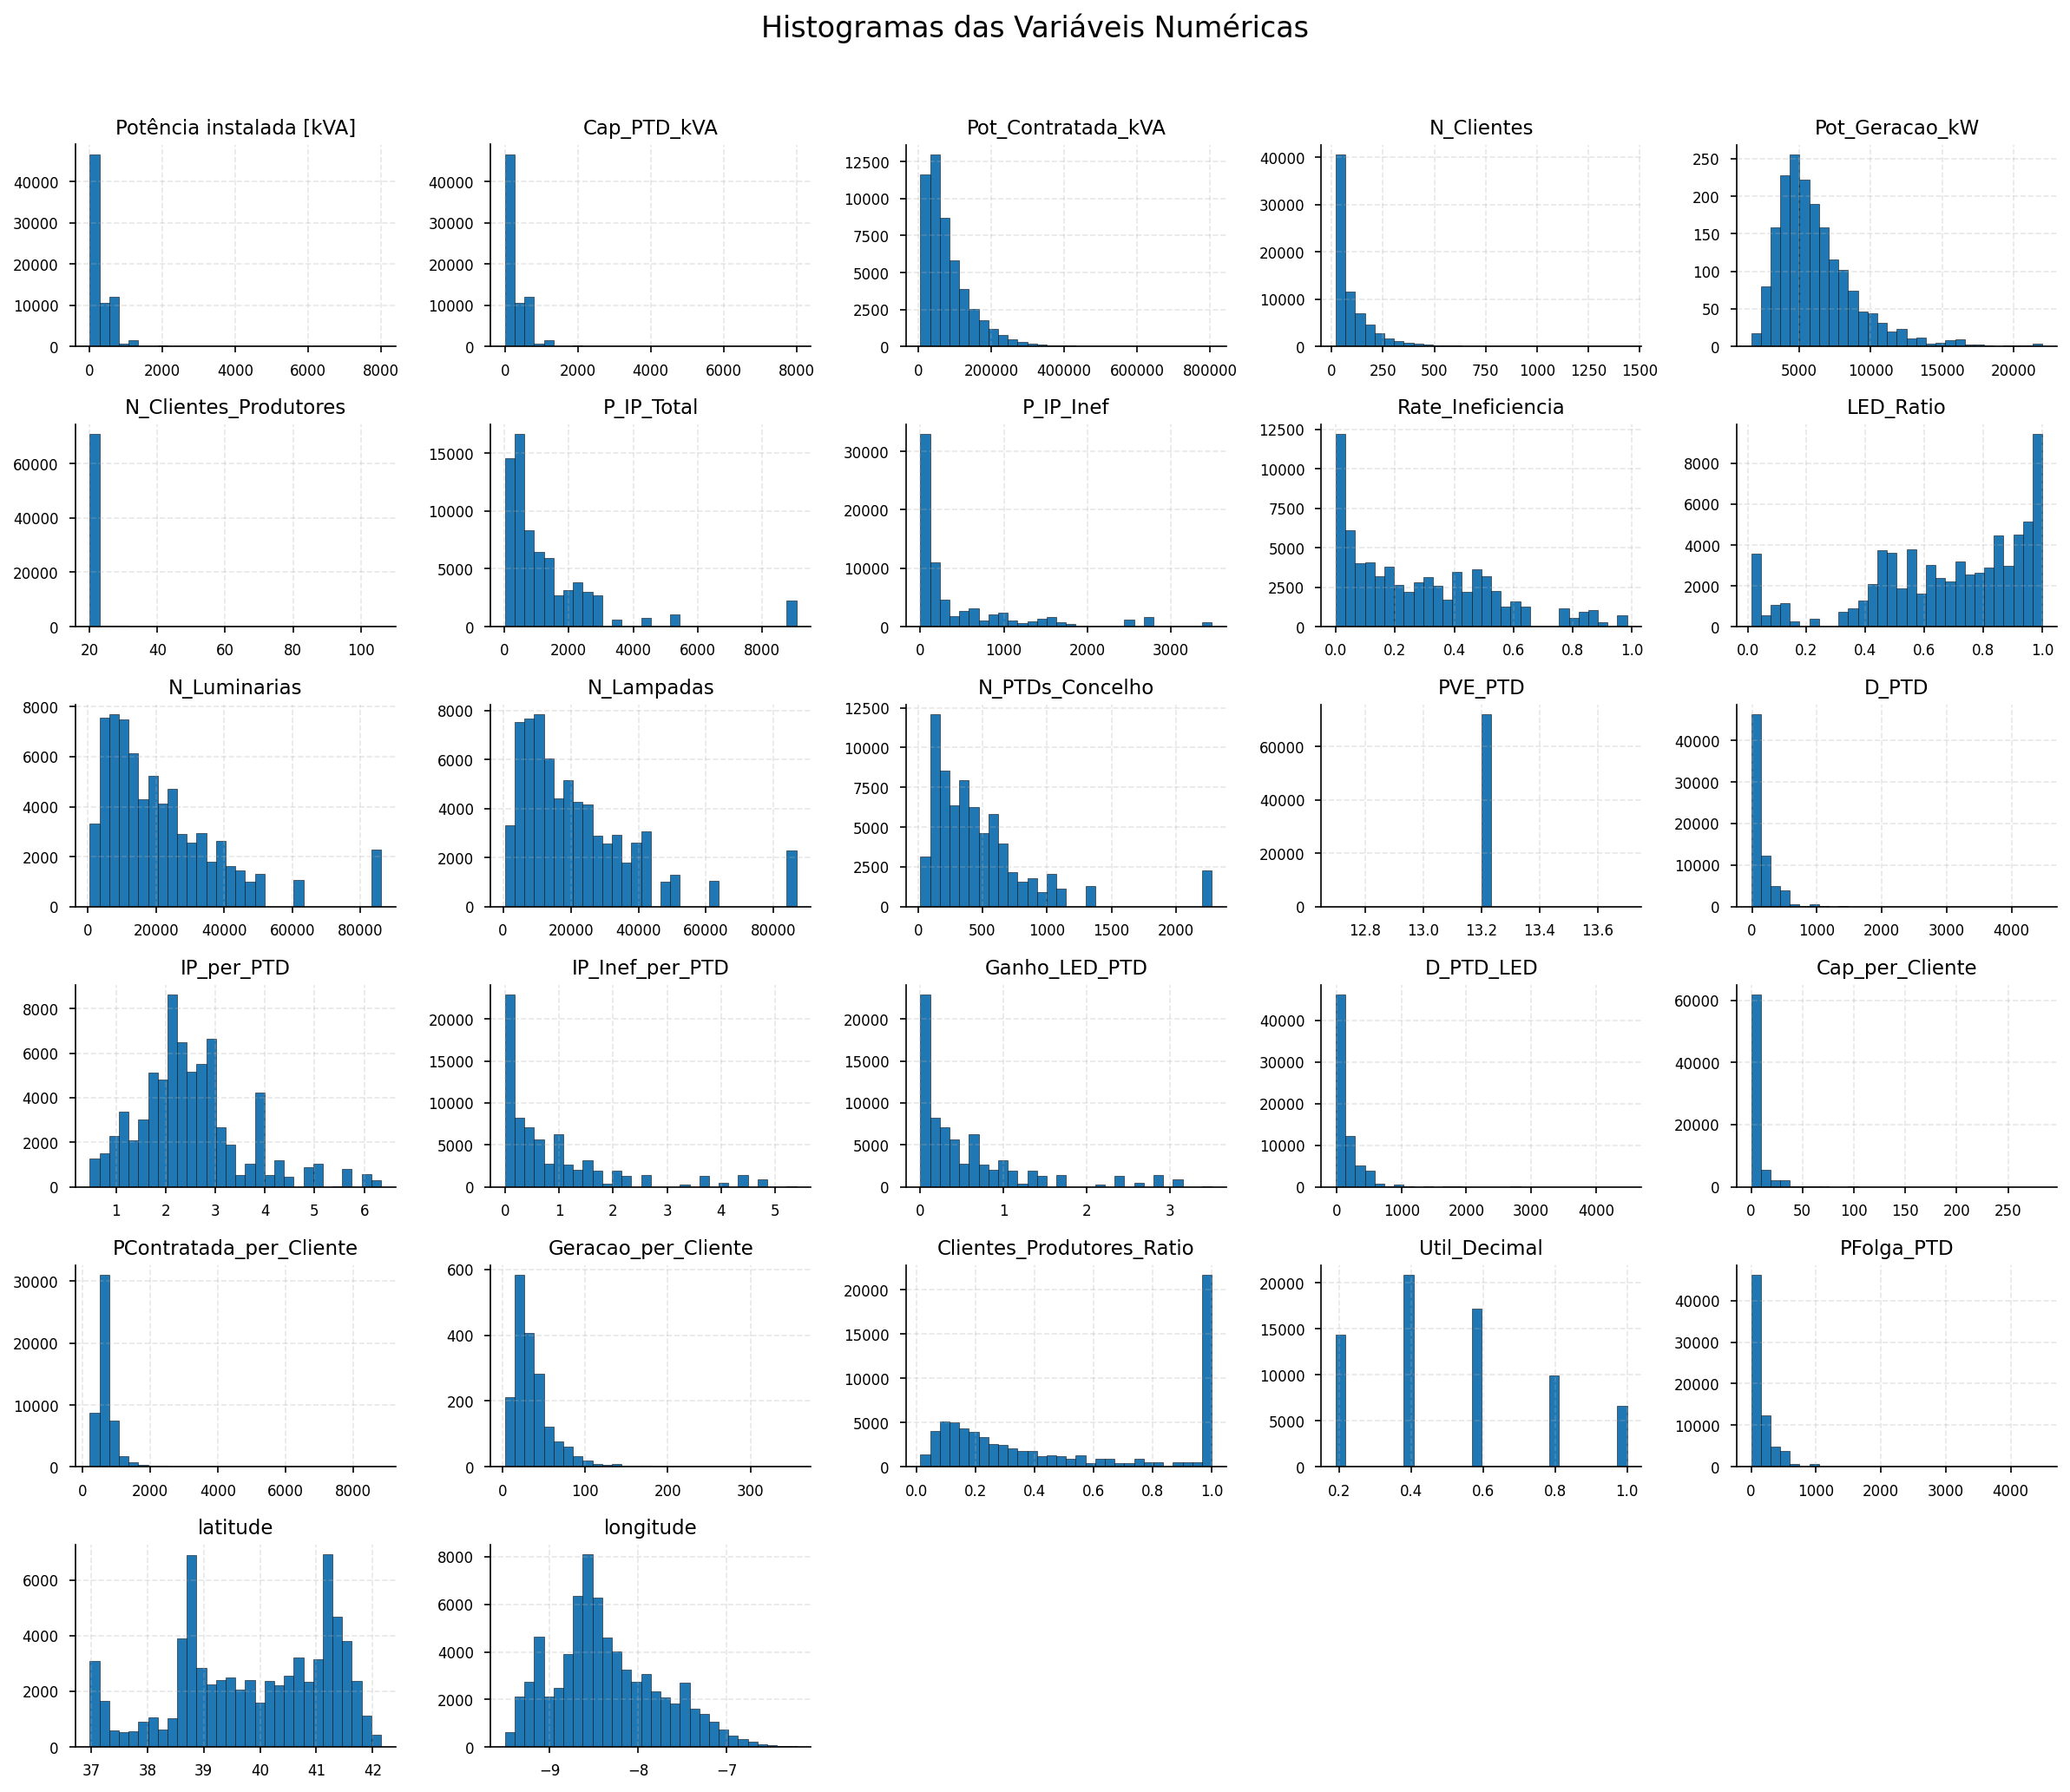

In [15]:
# Selecionar variáveis numéricas
numeric_df = df.select_dtypes(include=['number'])

# Criar histogramas para as variáveis numéricas
numeric_df.hist(figsize=(16, 14), bins=30, edgecolor='black')

plt.suptitle('Histogramas das Variáveis Numéricas', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar layout para não sobrepor o título
plt.show()


**Análise:** Histogramas de todas as variáveis numéricas, permitindo avaliar a forma
da distribuição (simetria, enviesamento, presença de caudas longas). [PREENCHER]:
notar quais variáveis apresentam distribuição fortemente assimétrica à direita
(tipicamente variáveis de "volume"/contagem como `N_Clientes`, `Cap_PTD_kVA`,
`P_IP_Total`) — isto justifica o uso de `RobustScaler` (em vez de `StandardScaler`)
no pré-processamento, e a estratégia de winsorization aplicada mais à frente.


/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/2018807543.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar layout para não sobrepor o título


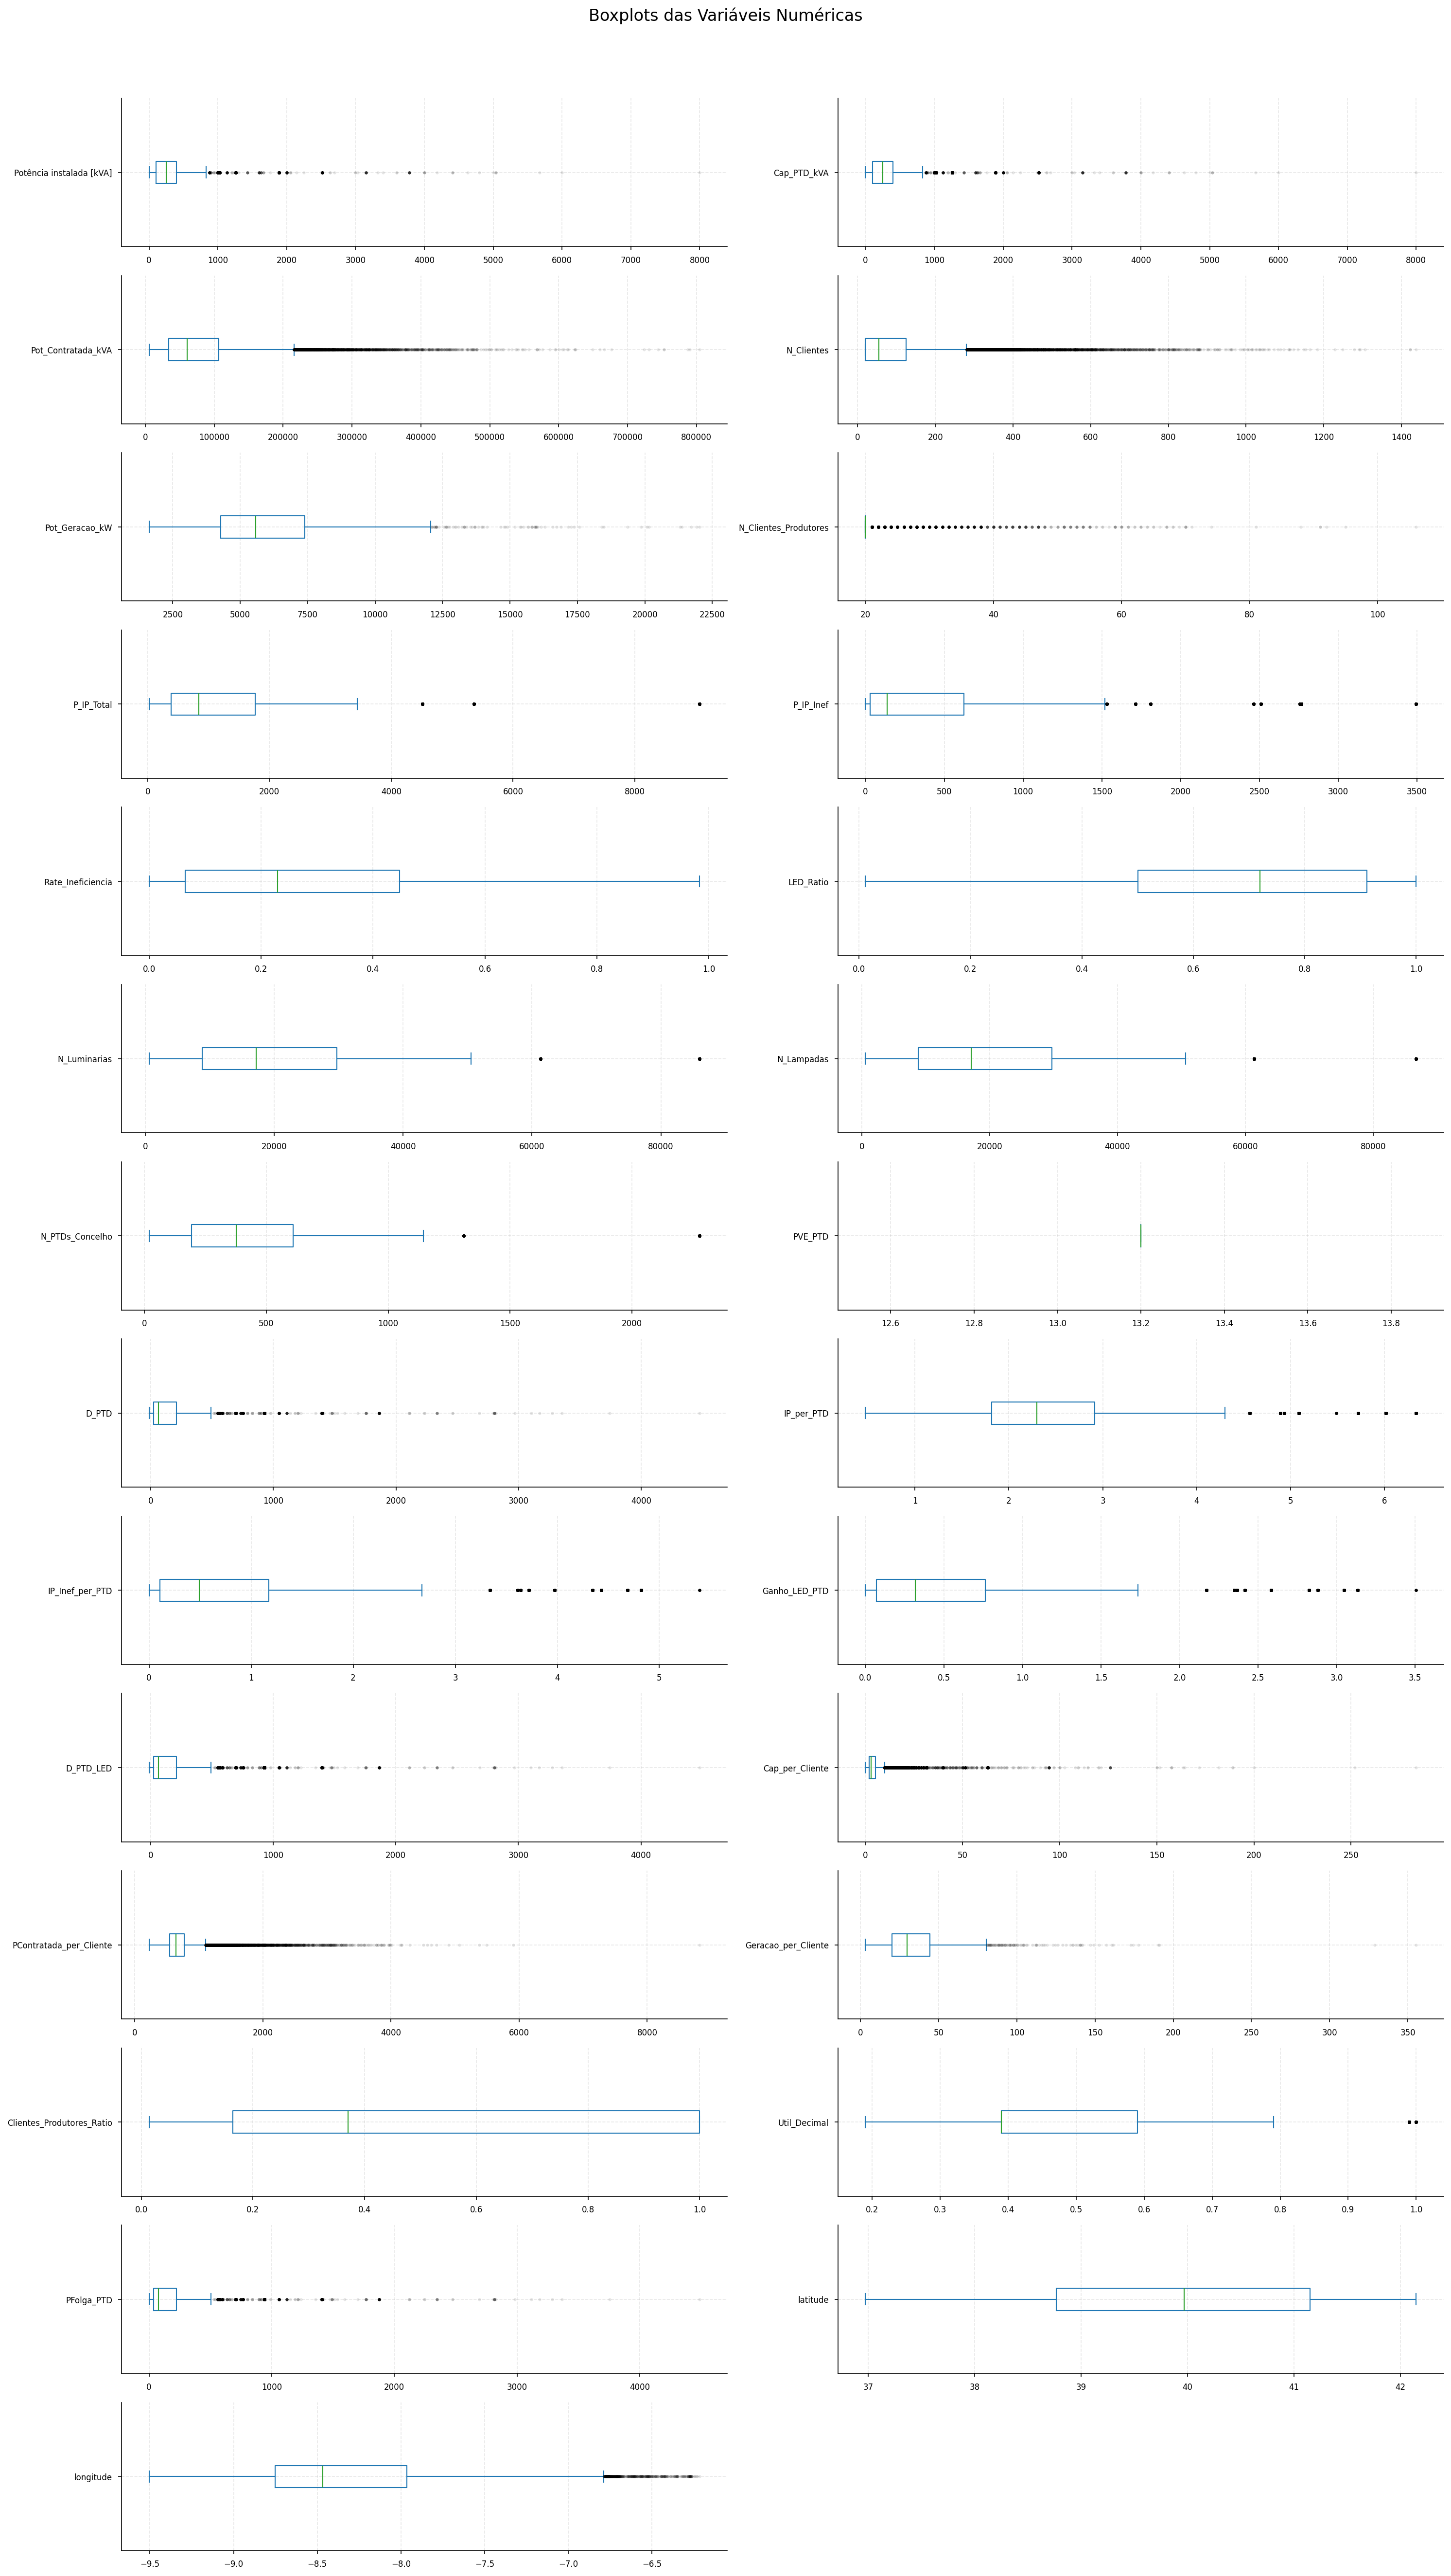

In [16]:
# Selecionar variáveis numéricas
numeric_df = df.select_dtypes(include=['number'])

num_cols = len(numeric_df.columns)
cols = 2
rows = math.ceil(num_cols / cols)

# Definir estilo dos outliers (fliers) com transparência e sem borda
# O parametro alpha=0.1 ajuda a visualizar onde há maior concentração de pontos
flierprops = dict(
    marker='o', 
    markerfacecolor='black', 
    markeredgecolor='none', 
    markersize=3, 
    alpha=0.1
)

# Criar boxplots em subplots separados
numeric_df.plot(
    kind='box', 
    subplots=True, 
    layout=(rows, cols), 
    figsize=(20, 36), 
    sharex=False, 
    sharey=False,
    fontsize=8,
    vert=False,
    flierprops=flierprops  # Aplicar a transparência aos outliers
)

plt.suptitle('Boxplots das Variáveis Numéricas', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar layout para não sobrepor o título
plt.show()


**Análise:** Boxplots horizontais de todas as variáveis numéricas, com os outliers
("fliers") desenhados com transparência para visualizar zonas de maior concentração.
[PREENCHER]: indicar quais variáveis apresentam mais outliers e se estes parecem
valores plausíveis (ex.: PTDs em zonas de alta densidade urbana, com capacidades e
nº de clientes muito superiores à média) ou potenciais erros de registo. Esta análise
fundamenta diretamente a estratégia de tratamento de outliers aplicada a seguir
(winsorization vs. imputação pela mediana, dependendo do tipo de variável).


#### Tratamento de nulos

In [17]:
# 1. Imputação de Zeros para Variáveis de Geração
# O elevado número de nulos nestas colunas (~70k) reflete que a esmagadora maioria dos postos não tem produção injetada. 
# Preencher com 0 é a abordagem lógica.
df['Pot_Geracao_kW'] = df['Pot_Geracao_kW'].fillna(0)
df['Geracao_per_Cliente'] = df['Geracao_per_Cliente'].fillna(0)

# 2. Imputação pela Mediana (Potência Contratada)
# Faltam cerca de 21 mil registos (~30%). Sendo demasiados para eliminar, usamos a Mediana para não criar viés através da Média (que é desvirtuada por outliers mesmo após winsorization limitativo).
median_pot_contratada = df['Pot_Contratada_kVA'].median()
df['Pot_Contratada_kVA'] = df['Pot_Contratada_kVA'].fillna(median_pot_contratada)

median_pcont_per_cliente = df['PContratada_per_Cliente'].median()
df['PContratada_per_Cliente'] = df['PContratada_per_Cliente'].fillna(median_pcont_per_cliente)

# 3. Eliminação de Registos (Elimination / Dropping)
# As restantes variáveis - ['D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PFolga_PTD'] - têm os exatos 3064 nulos em comum (aprox 4.2% dos dados).
# Como são indicadores-chave complexos de calcular que envolvem variáveis técnicas espaciais que provavelmente estão em falta na source, 
# a abordagem mais segura é eliminar as observações afetadas para assegurar a precisão do algoritmo.
cols_to_drop_na = ['D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PFolga_PTD']
df.dropna(subset=cols_to_drop_na, inplace=True)

print(f"Dimensão final do dataset pós-limpeza de nulos: {df.shape}")
missing_info = df.isnull().sum()
print("\\nValores nulos restantes:")
if len(missing_info[missing_info > 0]) == 0:
    print("Nenhum! O dataset está totalmente preenchido.")
else:
    print(missing_info[missing_info > 0])


Dimensão final do dataset pós-limpeza de nulos: (68963, 32)
\nValores nulos restantes:
Nenhum! O dataset está totalmente preenchido.



**Análise:** Tratamento de valores omissos, com três estratégias diferentes
justificadas pelo tipo de variável:
1. **Imputação por zero** para `Pot_Geracao_kW` e `Geracao_per_Cliente` — a esmagadora
   maioria dos PTDs (~70 mil) não tem produção distribuída associada, pelo que o nulo
   representa "sem geração" (zero é o valor correto, não um valor em falta).
2. **Imputação pela mediana** para `Pot_Contratada_kVA` e `PContratada_per_Cliente`
   (~30% de nulos) — a mediana é mais robusta a outliers do que a média, e o volume de
   nulos é demasiado grande para eliminar sem perder informação relevante.
3. **Eliminação de registos** para `D_PTD`, `D_PTD_LED`, `Util_Decimal` e
   `PFolga_PTD` (~3 064 registos, ~4.2%) — são as variáveis-alvo/derivadas mais
   complexas, dependentes de cálculos espaciais que podem estar em falta na fonte;
   como o volume é pequeno, a remoção é a opção mais segura para não introduzir ruído
   nas variáveis-alvo.

A célula confirma que, após estas três operações, o dataset fica sem nulos
(dimensão final reportada na saída). *Para o artigo (secção Pré-processamento):*
esta célula é central — deve ser resumida em texto e/ou numa tabela com (nº de
nulos antes, estratégia aplicada, justificação, nº de registos finais).


In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 68963 entries, 1307D2012500 to 1503D2067100
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Distrito                   68963 non-null  str     
 1   Concelho                   68963 non-null  str     
 2   CodDistritoConcelho        68963 non-null  category
 3   Potência instalada [kVA]   68963 non-null  int64   
 4   Tipo Construtivo           68963 non-null  str     
 5   Cap_PTD_kVA                68963 non-null  int64   
 6   Pot_Contratada_kVA         68963 non-null  float64 
 7   N_Clientes                 68963 non-null  int64   
 8   Pot_Geracao_kW             68963 non-null  float64 
 9   N_Clientes_Produtores      68963 non-null  int64   
 10  P_IP_Total                 68963 non-null  float64 
 11  P_IP_Inef                  68963 non-null  float64 
 12  Rate_Ineficiencia          68963 non-null  float64 
 13  LED_Ratio                  68


**Análise:** Confirma-se via `df.info()` que, após a célula anterior, todas as
colunas têm 100% de valores não-nulos e que o número total de registos se manteve
em torno de ~68 963 (após a remoção das ~3 064 linhas com nulos nas
variáveis-chave). [PREENCHER]: registar a dimensão final exata (`df.shape`) para
referenciar no artigo.


#### Tratamento de outliers

In [19]:
# Variáveis que representam "volumes" / quantidades (fortemente enviesadas à direita em zonas urbanas)
# Para estas, o valor ser muito alto é real (e.g., um posto numa zona de alta densidade),
# logo vamos aplicar WINSORIZATION (limitar aos valores de Z-score limiar) para não perder a informação.
cols_to_winsorize = [
    'Potência instalada [kVA]', 'Cap_PTD_kVA', 'Pot_Contratada_kVA', 
    'N_Clientes', 'N_PTDs_Concelho', 'P_IP_Total', 'P_IP_Inef',
    'N_Luminarias', 'N_Lampadas', 'Cap_per_Cliente', 'PContratada_per_Cliente'
]

# Variáveis relacionadas a produção (muitos zeros, alguns outliers enormes)
# Winsorization é útil aqui para abafar instalações que parecem centrais inteiras
cols_prod = [
    'Pot_Geracao_kW', 'N_Clientes_Produtores', 'Geracao_per_Cliente'
]

# Variáveis que são Rácios, Índices ou Percentagens. 
# Valores extremos podem ser erros de cálculo na base de dados original.
# Nesses casos, a imputação (por exemplo com a mediana) pode ser mais segura se os identificarmos como outliers.
cols_to_impute = [
    'Rate_Ineficiencia', 'LED_Ratio', 'Util_Decimal', 'PFolga_PTD', 
    'Clientes_Produtores_Ratio', 'IP_per_PTD', 'IP_Inef_per_PTD', 
    'Ganho_LED_PTD', 'D_PTD', 'D_PTD_LED', 'PVE_PTD'
]

z_thresh = 3

print("--- WINSORIZATION ---")
for col in cols_to_winsorize + cols_prod:
    if col not in df.columns: continue
    
    mean_val = df[col].mean()
    std_val = df[col].std()
    
    lower_bound = mean_val - z_thresh * std_val
    upper_bound = mean_val + z_thresh * std_val
    
    # As quantidades devem ser positivas
    if lower_bound < 0:
        lower_bound = 0
        
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_count = outliers_mask.sum()
    
    if outliers_count > 0:
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"[{col}] {outliers_count} outliers winsorizados.")
        
print("\n\n--- IMPUTATION (SUBSTITUIR POR MEDIANA) ---")
for col in cols_to_impute:
    if col not in df.columns: continue
    
    mean_val = df[col].mean()
    std_val = df[col].std()
    
    lower_bound = mean_val - z_thresh * std_val
    upper_bound = mean_val + z_thresh * std_val
    
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_count = outliers_mask.sum()
    
    if outliers_count > 0:
        median_val = df[col].median()
        # Imputar outliers com a mediana
        df.loc[outliers_mask, col] = median_val
        print(f"[{col}] {outliers_count} outliers imputados com a mediana ({median_val:.3f}).")
        
# Verificar se existem variáveis com valores muito absurdos fisicamente que precisemos remover (Trimming)
# ex: valores negativos de distâncias, ou taxas de utilização negativas
# Para taxas e ratios, elas deveriam estar entre 0 e 1 (ou 100%).
invalid_mask = pd.Series(False, index=df.index)

--- WINSORIZATION ---
[Potência instalada [kVA]] 1666 outliers winsorizados.
[Cap_PTD_kVA] 1666 outliers winsorizados.
[Pot_Contratada_kVA] 1421 outliers winsorizados.
[N_Clientes] 1405 outliers winsorizados.
[N_PTDs_Concelho] 2180 outliers winsorizados.
[P_IP_Total] 2180 outliers winsorizados.
[P_IP_Inef] 2310 outliers winsorizados.
[N_Luminarias] 2180 outliers winsorizados.
[N_Lampadas] 2180 outliers winsorizados.
[Cap_per_Cliente] 2382 outliers winsorizados.
[PContratada_per_Cliente] 1355 outliers winsorizados.
[Pot_Geracao_kW] 1619 outliers winsorizados.
[N_Clientes_Produtores] 721 outliers winsorizados.
[Geracao_per_Cliente] 1211 outliers winsorizados.


--- IMPUTATION (SUBSTITUIR POR MEDIANA) ---
[PFolga_PTD] 981 outliers imputados com a mediana (77.280).
[IP_per_PTD] 819 outliers imputados com a mediana (2.299).
[IP_Inef_per_PTD] 2200 outliers imputados com a mediana (0.490).
[Ganho_LED_PTD] 2200 outliers imputados com a mediana (0.319).
[D_PTD] 981 outliers imputados com a medi


**Análise:** Tratamento de outliers usando o critério de **Z-score** (|z| > 3),
com três grupos de variáveis tratados de forma diferenciada:
- **Winsorization** (corte/"clip" aos limites ±3σ) para variáveis de "volume"
  (capacidades, nº de clientes, IP, luminárias) — valores extremos são reais (PTDs em
  zonas de muita densidade) e por isso são *limitados*, não eliminados, preservando a
  informação de que são "valores altos" sem deixar que dominem o treino dos modelos.
- **Winsorization** também para as variáveis de produção (`Pot_Geracao_kW`,
  `N_Clientes_Produtores`, `Geracao_per_Cliente`), pelo mesmo motivo (poucos PTDs com
  produção muito elevada).
- **Imputação pela mediana** para rácios/índices/percentagens (`Rate_Ineficiencia`,
  `LED_Ratio`, `Util_Decimal`, `PFolga_PTD`, etc.) — para estas variáveis, valores
  muito fora do intervalo esperado são mais provavelmente erros de cálculo do que
  valores reais extremos, pelo que a substituição pela mediana é a opção mais segura.

A saída lista, para cada variável, quantos outliers foram winsorizados/imputados e o
valor da mediana usado. [PREENCHER]: destacar no artigo as variáveis com maior número
de outliers tratados (ex.: `Cap_per_Cliente`, `N_PTDs_Concelho`, `IP_Inef_per_PTD`,
`Ganho_LED_PTD`) e interpretar — tipicamente associadas a concelhos pequenos/grandes
ou a PTDs atípicos.


#### Testes de Independencia ANOVA (PFolga_PTD)

In [20]:
target_var = 'PFolga_PTD'
alpha = 0.05

print(f"--- ANÁLISE DE INDEPENDÊNCIA COM A TARGET: {target_var} ---\n")

# Para armazenar resultados
results = []
vars_to_keep = []

# Separar numéricas (correlação de Pearson/Spearman) e categóricas (ANOVA/Kruskal)
num_cols_test = df.select_dtypes(include=['number']).columns.drop(target_var)
cat_cols_test = df.select_dtypes(include=['object', 'category']).columns

# 1. TESTE PARA VARIÁVEIS NUMÉRICAS (Correlação de Spearman - mais robuso que Pearson)
for col in num_cols_test:
    # Retirar nulos (se houver algum extra) para o teste
    valid_data = df[[col, target_var]].dropna()
    
    if len(valid_data) > 1:
        corr, p_value = stats.spearmanr(valid_data[col], valid_data[target_var])
        keep = 'Yes' if p_value < alpha else 'No'
        if keep == 'Yes': vars_to_keep.append(col)
            
        results.append({
            'Variável': col,
            'Tipo': 'Numérica',
            'Teste': 'Spearman Correlation',
            'Estatística (Corr/F)': corr,
            'P-Value': p_value,
            'Manter (p < 0.05)': keep
        })

# 2. TESTES PARA VARIÁVEIS CATEGÓRICAS (ANOVA)
for col in cat_cols_test:
    valid_data = df[[col, target_var]].dropna()
    groups = [group[target_var].values for name, group in valid_data.groupby(col)]
    
    # Executar ANOVA apenas se tivermos mais que um grupo e dados suficientes
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
        keep = 'Yes' if p_value < alpha else 'No'
        if keep == 'Yes': vars_to_keep.append(col)
            
        results.append({
            'Variável': col,
            'Tipo': 'Categórica',
            'Teste': 'ANOVA (F-oneway)',
            'Estatística (Corr/F)': f_stat,
            'P-Value': p_value,
            'Manter (p < 0.05)': keep
        })

# 3. EXIBIR TABELA
results_df = pd.DataFrame(results)

# Formatar para exibição limpa
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.5f}')
print(results_df.sort_values(by='P-Value').to_string(index=False))

print("\n--- CONCLUSÃO ---")
print(f"Número total de variáveis testadas: {len(results_df)}")
print(f"Número de variáveis sugeridas a MANTER (associadas à target): {len(vars_to_keep)}")
print(f"Variáveis a DESCARTAR (Independentes da target, p >= 0.05): \n{results_df[results_df['Manter (p < 0.05)'] == 'No']['Variável'].tolist()}")

--- ANÁLISE DE INDEPENDÊNCIA COM A TARGET: PFolga_PTD ---

                 Variável       Tipo                Teste  Estatística (Corr/F)  P-Value Manter (p < 0.05)
 Potência instalada [kVA]   Numérica Spearman Correlation               0.81471  0.00000               Yes
      CodDistritoConcelho Categórica     ANOVA (F-oneway)              74.50563  0.00000               Yes
                 Concelho Categórica     ANOVA (F-oneway)              74.50563  0.00000               Yes
                 Distrito Categórica     ANOVA (F-oneway)             566.54451  0.00000               Yes
                longitude   Numérica Spearman Correlation              -0.29203  0.00000               Yes
             Util_Decimal   Numérica Spearman Correlation              -0.53893  0.00000               Yes
Clientes_Produtores_Ratio   Numérica Spearman Correlation              -0.23758  0.00000               Yes
  PContratada_per_Cliente   Numérica Spearman Correlation               0.17248  0.00

/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/3860725695.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_test = df.select_dtypes(include=['object', 'category']).columns
/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/3860725695.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.spearmanr(valid_data[col], valid_data[target_var])



**Análise:** Teste de independência entre cada variável e o alvo `PFolga_PTD`,
usando **correlação de Spearman** para variáveis numéricas (mais robusta a relações
não-lineares e a outliers do que Pearson) e **ANOVA one-way** para variáveis
categóricas, com nível de significância α=0.05. A tabela de resultados ordena as
variáveis por p-value e indica quais devem ser "mantidas" (p < 0.05, associação
estatisticamente significativa com `PFolga_PTD`) e quais "descartadas" (p ≥ 0.05,
aparentemente independentes do alvo). [PREENCHER]: listar no artigo as variáveis
identificadas como independentes (a descartar) e justificar a sua remoção — por
exemplo, `PVE_PTD` é removida explicitamente na célula seguinte com base neste
teste. *Para o artigo (secção "Seleção de Variáveis"):* esta é a justificação
estatística formal para a seleção de features feita ao longo do trabalho — deve ser
referenciada como parte do critério de seleção, complementar à análise de correlação
de Pearson (cell 25/38).


In [21]:
df.drop(columns="PVE_PTD", inplace=True)


**Análise:** Remove-se a variável `PVE_PTD` do dataset, com base no resultado do
teste de independência da célula anterior (não associada significativamente a
`PFolga_PTD`, p ≥ 0.05). *Para o artigo:* mencionar esta remoção como exemplo
concreto da aplicação do critério estatístico de seleção de variáveis (4.1 —
"seleção de variáveis relevantes" exigida pelo enunciado).


### Drop IDs

Eliminar variáveis 

# 4.2 Modelos de Regressão

/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/3260512837.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_alvo.values, y=corr_alvo.index, palette='viridis')
/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/3260512837.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


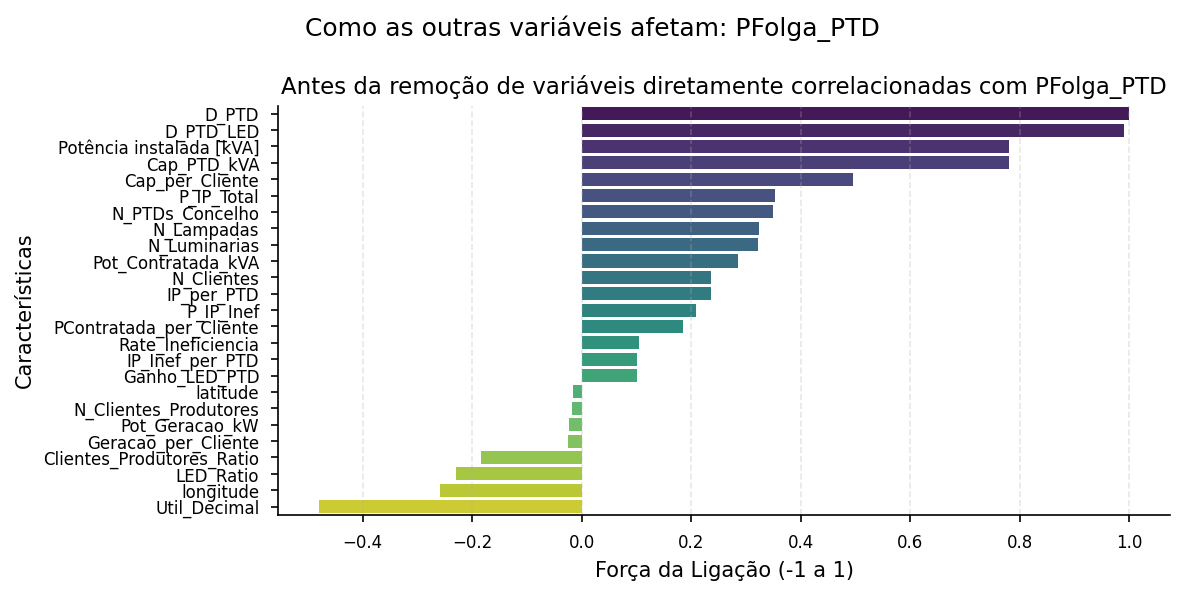

In [22]:
# 
def show_correlations(df, variavel_alvo, title = "Antes da remoção de variáveis diretamente correlacionadas com PFolga_PTD" ):
    # Calcular as ligações
    num_df = df.select_dtypes(include=['number'])

    correlacao = num_df.corr()
    
    # Isolar a variável desejada e ordená-la
    corr_alvo = correlacao[variavel_alvo].drop(variavel_alvo).sort_values(ascending=False)
    
    # Criar o gráfico
    plt.figure(figsize=(8, 4))
    sns.barplot(x=corr_alvo.values, y=corr_alvo.index, palette='viridis')
    
    # Textos do gráfico ajustados automaticamente ao nome da variável
    plt.title(title)
    plt.suptitle(f'Como as outras variáveis afetam: {variavel_alvo}')
    plt.xlabel('Força da Ligação (-1 a 1)')
    plt.ylabel('Características')
    plt.tight_layout()
    plt.show()
    
    
show_correlations(df, "PFolga_PTD")
    


**Análise:** Define-se uma função auxiliar `show_correlations` que calcula e
visualiza, num gráfico de barras horizontais, a correlação de Pearson entre
`PFolga_PTD` e todas as restantes variáveis numéricas, ordenadas por força (positiva
a negativa). A primeira chamada mostra o estado **antes** da remoção de variáveis
altamente correlacionadas. [PREENCHER]: identificar as variáveis com correlação mais
forte (positiva e negativa) com `PFolga_PTD` — esperam-se correlações muito elevadas
com `D_PTD`/`D_PTD_LED` (que são, por definição/derivação, próximas do alvo) e
correlações moderadas com `Cap_per_Cliente`, `Util_Decimal`, etc. *Para o artigo
(secção 4.2.1, "diagrama de correlação"):* esta figura é exatamente o que o enunciado
pede no ponto 1 da secção de Regressão — incluir e interpretar, destacando as
variáveis mais fortemente associadas a `PFolga_PTD`.


In [23]:
# 1. Definir o limiar e o alvo
threshold = 0.95
target_var = 'PFolga_PTD'

print("--- REMOÇÃO DE VARIÁVEIS ALTAMENTE CORRELACIONADAS COM O ALVO ---")

# 2. Selecionar APENAS as colunas com números da tabela
num_df = df.select_dtypes(include=['number'])

# 2. Calcular a força da ligação de todas as variáveis APENAS com o alvo
corr_com_alvo = num_df.corr()[target_var].abs()

# 3. Escolher as que passam dos 0.95 (excluindo o próprio alvo, que é 1.0)
to_drop = corr_com_alvo[(corr_com_alvo > threshold) & (corr_com_alvo.index != target_var)].index.tolist()

print(f"Variáveis a remover ({threshold}): {to_drop}")

# 4. Remover da tabela
df.drop(columns=to_drop, inplace=True)

print(f"Dimensão final: {df.shape}")

--- REMOÇÃO DE VARIÁVEIS ALTAMENTE CORRELACIONADAS COM O ALVO ---
Variáveis a remover (0.95): ['D_PTD', 'D_PTD_LED']
Dimensão final: (68963, 29)



**Análise:** Remoção automática de variáveis com correlação |r| > 0.95 com o alvo
`PFolga_PTD`, para evitar *data leakage* (variáveis que são, na prática, quase
redundantes/derivadas diretamente do alvo e que dariam aos modelos uma "vantagem
injusta", não generalizável). A saída identifica `D_PTD` e `D_PTD_LED` como as
variáveis removidas (dimensão final do dataset reportada). *Para o artigo:*
justificar esta remoção — `D_PTD` e `D_PTD_LED` representam o "Saldo Final de
Viabilidade" calculado no TP1, que partilha a mesma base de cálculo que
`PFolga_PTD` (folga de rede), pelo que a sua inclusão tornaria a tarefa de regressão
trivial e sem valor preditivo real.


/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/3260512837.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_alvo.values, y=corr_alvo.index, palette='viridis')
/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_10446/3260512837.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


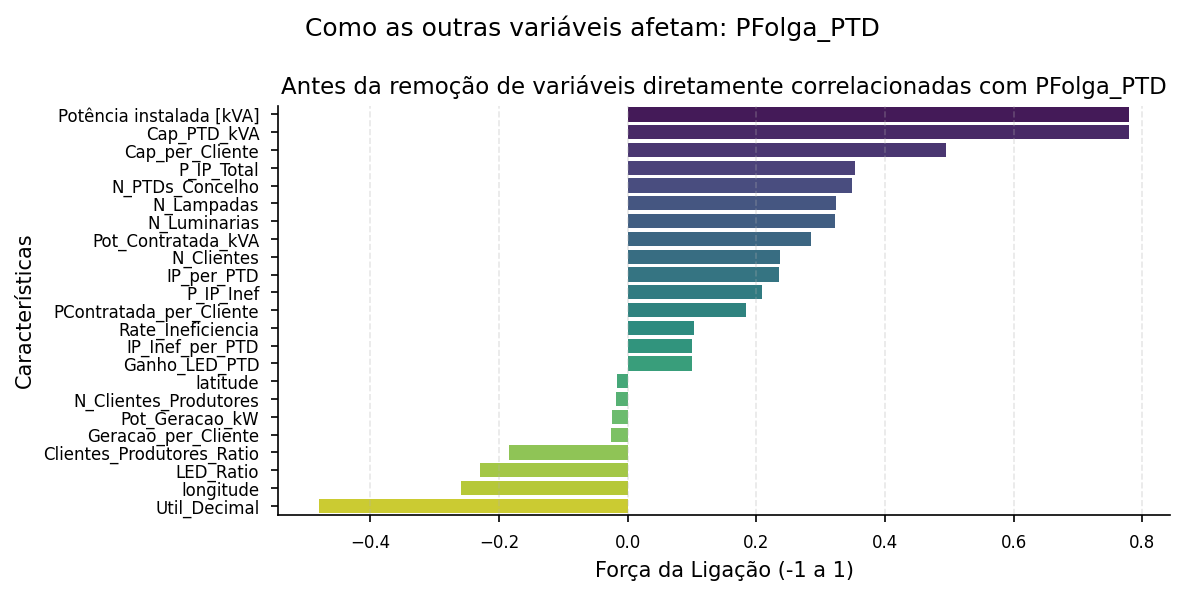

In [24]:
show_correlations(df, "PFolga_PTD")


**Análise:** Repete-se o gráfico de correlações com `PFolga_PTD`, agora **depois** da
remoção de `D_PTD`/`D_PTD_LED`. [PREENCHER]: comparar com a figura da célula 38 —
as correlações remanescentes mais fortes (provavelmente `Cap_per_Cliente`,
`Util_Decimal`, `N_Clientes`, `Rate_Ineficiencia`, etc.) tornam-se as candidatas
naturais à variável explicativa da regressão linear simples (célula 43). *Para o
artigo:* esta figura "depois" complementa a figura "antes" — juntas, ilustram
visualmente o processo de seleção de variáveis e a justificação da escolha da
variável explicativa para a regressão simples.


In [25]:
df.head()

,Distrito,Concelho,CodDistritoConcelho,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD,latitude,longitude
Código de Instalação,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1307D2012500,Porto,Marco de Canaveses,1307,400.00000,Cabine pré-fabricada,400.00000,105269.00000,131.00000,0.00000,20.00000,1307.02450,991.25000,0.75840,0.23978,21315.00000,21286.00000,371.00000,3.52298,2.67183,1.73669,3.05344,803.58015,0.00000,0.15267,60%-79%,0.79000,77.28000,41.18490,-8.14785
1307D2012900,Porto,Marco de Canaveses,1307,250.00000,Cabine baixa integrada em edifício,250.00000,77520.00000,115.00000,0.00000,20.00000,1307.02450,991.25000,0.75840,0.23978,21315.00000,21286.00000,371.00000,3.52298,2.67183,1.73669,2.17391,674.08696,0.00000,0.17391,60%-79%,0.79000,48.30000,41.08699,-8.24673
1307D2013100,Porto,Marco de Canaveses,1307,250.00000,Cabine alta,250.00000,110419.00000,176.00000,0.00000,20.00000,1307.02450,991.25000,0.75840,0.23978,21315.00000,21286.00000,371.00000,3.52298,2.67183,1.73669,1.42045,627.38068,0.00000,0.11364,60%-79%,0.79000,48.30000,41.11292,-8.21277
1307D2013800,Porto,Marco de Canaveses,1307,50.00000,Aéreo - AS,50.00000,23807.00000,36.00000,0.00000,20.00000,1307.02450,991.25000,0.75840,0.23978,21315.00000,21286.00000,371.00000,3.52298,2.67183,1.73669,1.38889,661.30556,0.00000,0.55556,+100%,1.00000,0.00000,41.13295,-8.13563
1307D2015100,Porto,Marco de Canaveses,1307,250.00000,Aéreo - AI,250.00000,60851.00000,94.00000,0.00000,20.00000,1307.02450,991.25000,0.75840,0.23978,21315.00000,21286.00000,371.00000,3.52298,2.67183,1.73669,2.65957,647.35106,0.00000,0.21277,0%-19%,0.19000,186.30000,41.12284,-8.11290



**Análise:** `df.head()` mostra o estado atual do dataset após todas as transformações
de pré-processamento (tratamento de nulos, outliers, remoção de variáveis
redundantes/independentes, criação de `latitude`/`longitude`). [PREENCHER]: confirmar
o número final de colunas e o tipo de cada uma — esta é a versão "limpa" do dataset
que será usada como base para os modelos de regressão (4.2) e, mais tarde, de
classificação (4.3).


## Regressão Linear Simples 

JUSTIFICAÇÃO: Escolheu-se a variável 'Potência instalada [kVA]' pois apresenta a correlação mais forte (0.7799) com a PFolga_PTD, sendo a melhor candidata para explicar o seu comportamento.

--- c) MÉTRICAS DE ERRO (K-Fold) ---
MAE  (Média da margem de erro): 56.0721
RMSE (Penaliza erros grandes):  88.3765

--- a) FUNÇÃO LINEAR RESULTANTE ---
PFolga_PTD = (0.4398 * Potência instalada [kVA]) + 3.1480



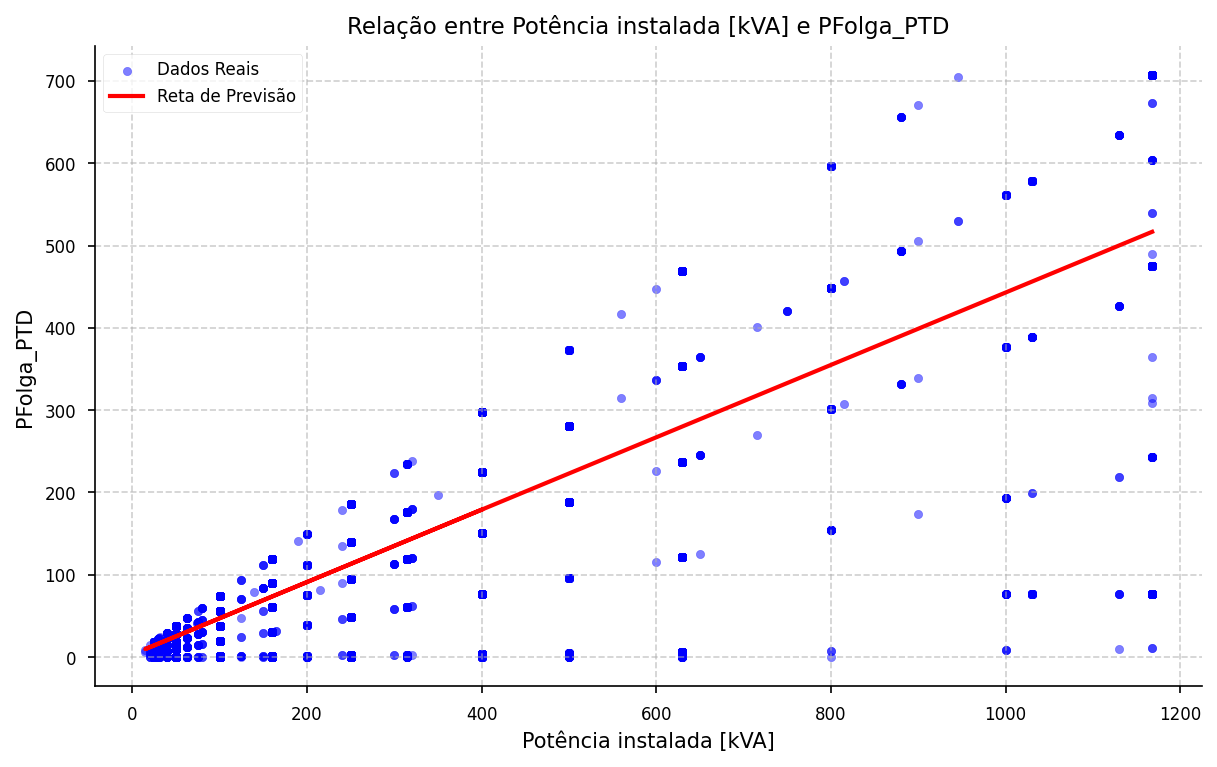

In [26]:
# ---------------------------------------------------------
# JUSTIFICAÇÃO E ESCOLHA DA VARIÁVEL
# ---------------------------------------------------------
alvo = 'PFolga_PTD'

# Analisa apenas os números e escolhe a variável com a ligação mais forte
df_numerico = df.select_dtypes(include=['number'])
correlacoes = df_numerico.corr()[alvo].abs().drop(alvo)
melhor_var = correlacoes.idxmax()

print(f"JUSTIFICAÇÃO: Escolheu-se a variável '{melhor_var}' pois apresenta a correlação mais forte ({correlacoes[melhor_var]:.4f}) com a {alvo}, sendo a melhor candidata para explicar o seu comportamento.\n")

X = df[[melhor_var]]
y = df[alvo]
modelo = LinearRegression()

# ---------------------------------------------------------
# c) CALCULAR ERROS COM K-FOLD (5 fatias)
# ---------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_resultados = cross_validate(modelo, X, y, cv=kf, scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error'))

mae_kfold = -cv_resultados['test_neg_mean_absolute_error'].mean()
rmse_kfold = -cv_resultados['test_neg_root_mean_squared_error'].mean()

print("--- c) MÉTRICAS DE ERRO (K-Fold) ---")
print(f"MAE  (Média da margem de erro): {mae_kfold:.4f}")
print(f"RMSE (Penaliza erros grandes):  {rmse_kfold:.4f}\n")

# ---------------------------------------------------------
# a) APRESENTAR A FUNÇÃO LINEAR RESULTANTE
# ---------------------------------------------------------
# Treinamos com tudo para ter a reta oficial
modelo.fit(X, y)
inclinacao = modelo.coef_[0]
intersecao = modelo.intercept_

print("--- a) FUNÇÃO LINEAR RESULTANTE ---")
print(f"{alvo} = ({inclinacao:.4f} * {melhor_var}) + {intersecao:.4f}\n")

# ---------------------------------------------------------
# b) VISUALIZAR A RETA E O DIAGRAMA DE DISPERSÃO
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

# Os pontos soltos (diagrama de dispersão)
plt.scatter(X, y, color='blue', alpha=0.5, label='Dados Reais')

# A linha de previsão (reta de regressão)
plt.plot(X, modelo.predict(X), color='red', linewidth=2, label='Reta de Previsão')

plt.title(f'Relação entre {melhor_var} e {alvo}')
plt.xlabel(melhor_var)
plt.ylabel(alvo)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Análise — Regressão Linear Simples (4.2.2):** A variável explicativa é escolhida
automaticamente como a que tem maior correlação absoluta com `PFolga_PTD` (impressa
na justificação). Usa-se **k-fold cross validation** (k=5, `shuffle=True`,
`random_state=42`) para calcular MAE e RMSE médios do modelo de regressão linear
simples. Apresenta-se também a **função linear resultante** (coeficiente e
intercepto, treinados sobre todo o dataset) e o **diagrama de dispersão com a reta
de regressão**.

[PREENCHER] *Para o artigo (secção 4.2.2):*
- Reportar o nome da variável escolhida (`melhor_var`) e a correlação correspondente.
- Apresentar a fórmula `PFolga_PTD = a·X + b` com os valores reais de `a` (inclinação)
  e `b` (intercepto).
- Reportar MAE e RMSE obtidos por k-fold.
- Interpretar a figura: se os pontos estão muito dispersos em torno da reta, é
  indicativo de que uma só variável explica apenas uma parte da variabilidade de
  `PFolga_PTD` — o que motiva os modelos multivariados seguintes (4.2.3).


## Regressão linear Múltipla

In [27]:
alvo = 'PFolga_PTD'
X = df.drop(columns=[alvo])
y = df[alvo]


**Análise:** Define-se o conjunto de dados para os modelos multivariados:
`X` contém todas as variáveis explicativas (todo o `df` exceto o alvo), e `y` é a
variável-alvo `PFolga_PTD`. A partir desta célula, todos os modelos de regressão
(4.2.3 a 4.2.6) usam este mesmo `X`/`y` como base.


In [28]:
#=====================================================
# 1. DETECT COLUMN TYPES
# =====================================================

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

ordinal_cols = ['Nível de Utilização [%]']
categorical_cols = [c for c in categorical_cols if c not in ordinal_cols]

# =====================================================
# 2. PREPROCESSOR
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('numeros', RobustScaler(), numeric_cols),
        ('ordinais', OrdinalEncoder(), ordinal_cols),
        ('texto', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# =====================================================
# 3. PIPELINE (MODEL)
# =====================================================

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# =====================================================
# 4. TRAIN / TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# 5. TRAIN MODEL
# =====================================================

model.fit(X_train, y_train)

# =====================================================
# 6. EXTRACT MODEL PARAMETERS
# =====================================================

reg = model.named_steps['regressor']
coefs = reg.coef_
intercept = reg.intercept_

# Feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# =====================================================
# 7. FEATURE IMPORTANCE TABLE
# =====================================================

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

importance_df["abs_coefficient"] = importance_df["coefficient"].abs()
importance_df = importance_df.sort_values("abs_coefficient", ascending=False)

print("\nTOP 20 FEATURES:")
print(importance_df.head(20))

# =====================================================
# 8. FULL LINEAR FORMULA
# =====================================================

terms = [
    f"({c:.4f} * {f})"
    for c, f in zip(coefs, feature_names)
]

formula = "y = " + f"{intercept:.4f} + " + " + ".join(terms)

print("\nLINEAR REGRESSION FORMULA:\n")
print(formula)

# =====================================================
# 9. MODEL EVALUATION (OPTIONAL)
# =====================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nEVALUATION:")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")


TOP 20 FEATURES:
                                          feature  coefficient  abs_coefficient
1                            numeros__Cap_PTD_kVA     45.26145         45.26145
0               numeros__Potência instalada [kVA]     45.26145         45.26145
19             numeros__Clientes_Produtores_Ratio    -43.33813         43.33813
20                          numeros__Util_Decimal    -37.23981         37.23981
606    texto__Tipo Construtivo_Cabine subterrânea     31.18945         31.18945
37                        texto__Distrito_Setúbal    -24.74540         24.74540
600            texto__Tipo Construtivo_Aéreo - AS    -22.56154         22.56154
599            texto__Tipo Construtivo_Aéreo - AI    -22.11120         22.11120
598             texto__Tipo Construtivo_Aéreo - A    -20.87050         20.87050
605  texto__Tipo Construtivo_Cabine pré-fabricada     20.11445         20.11445
21                              numeros__latitude    -18.60727         18.60727
27                    


**Análise:** Constrói-se o `preprocessor` (um `ColumnTransformer`) que será reutilizado
em todos os modelos de regressão seguintes:
- `RobustScaler` para variáveis numéricas (robusto a outliers, coerente com a
  decisão de winsorization tomada na EDA).
- `OrdinalEncoder` para `Nível de Utilização [%]` (variável ordinal).
- `OneHotEncoder` para as restantes variáveis categóricas (ex.: `Distrito`,
  `Concelho`, `Tipo Construtivo`, `CodDistritoConcelho`).

É treinado um modelo de **Regressão Linear Múltipla** (com *train/test split* 80/20)
e extraída a **fórmula linear completa** (com todos os coeficientes, após
codificação) e a tabela das 20 features com maior coeficiente absoluto. Também se
reportam MSE, RMSE e MAE no conjunto de teste.

[PREENCHER] *Para o artigo (secção 4.2.3a):*
- Reportar MAE/RMSE deste split fixo como referência inicial (note-se que a
  comparação "oficial" entre modelos, feita na secção 4.2.4, usa k-fold em vez de um
  único split — referir esta diferença metodológica).
- Da tabela de 20 features, identificar e discutir as 3–5 com maior peso absoluto —
  ajudam a responder à pergunta "quais as variáveis mais relevantes" pedida no ponto
  4 da secção de Regressão.
- ATENÇÃO: dado o elevado número de categorias em `Distrito`/`Concelho`/
  `CodDistritoConcelho` após One-Hot Encoding, a fórmula linear completa pode ter
  centenas de termos — no artigo, apresentar apenas as features mais relevantes
  (não a fórmula completa).


Decision Tree MAE: 8.0962



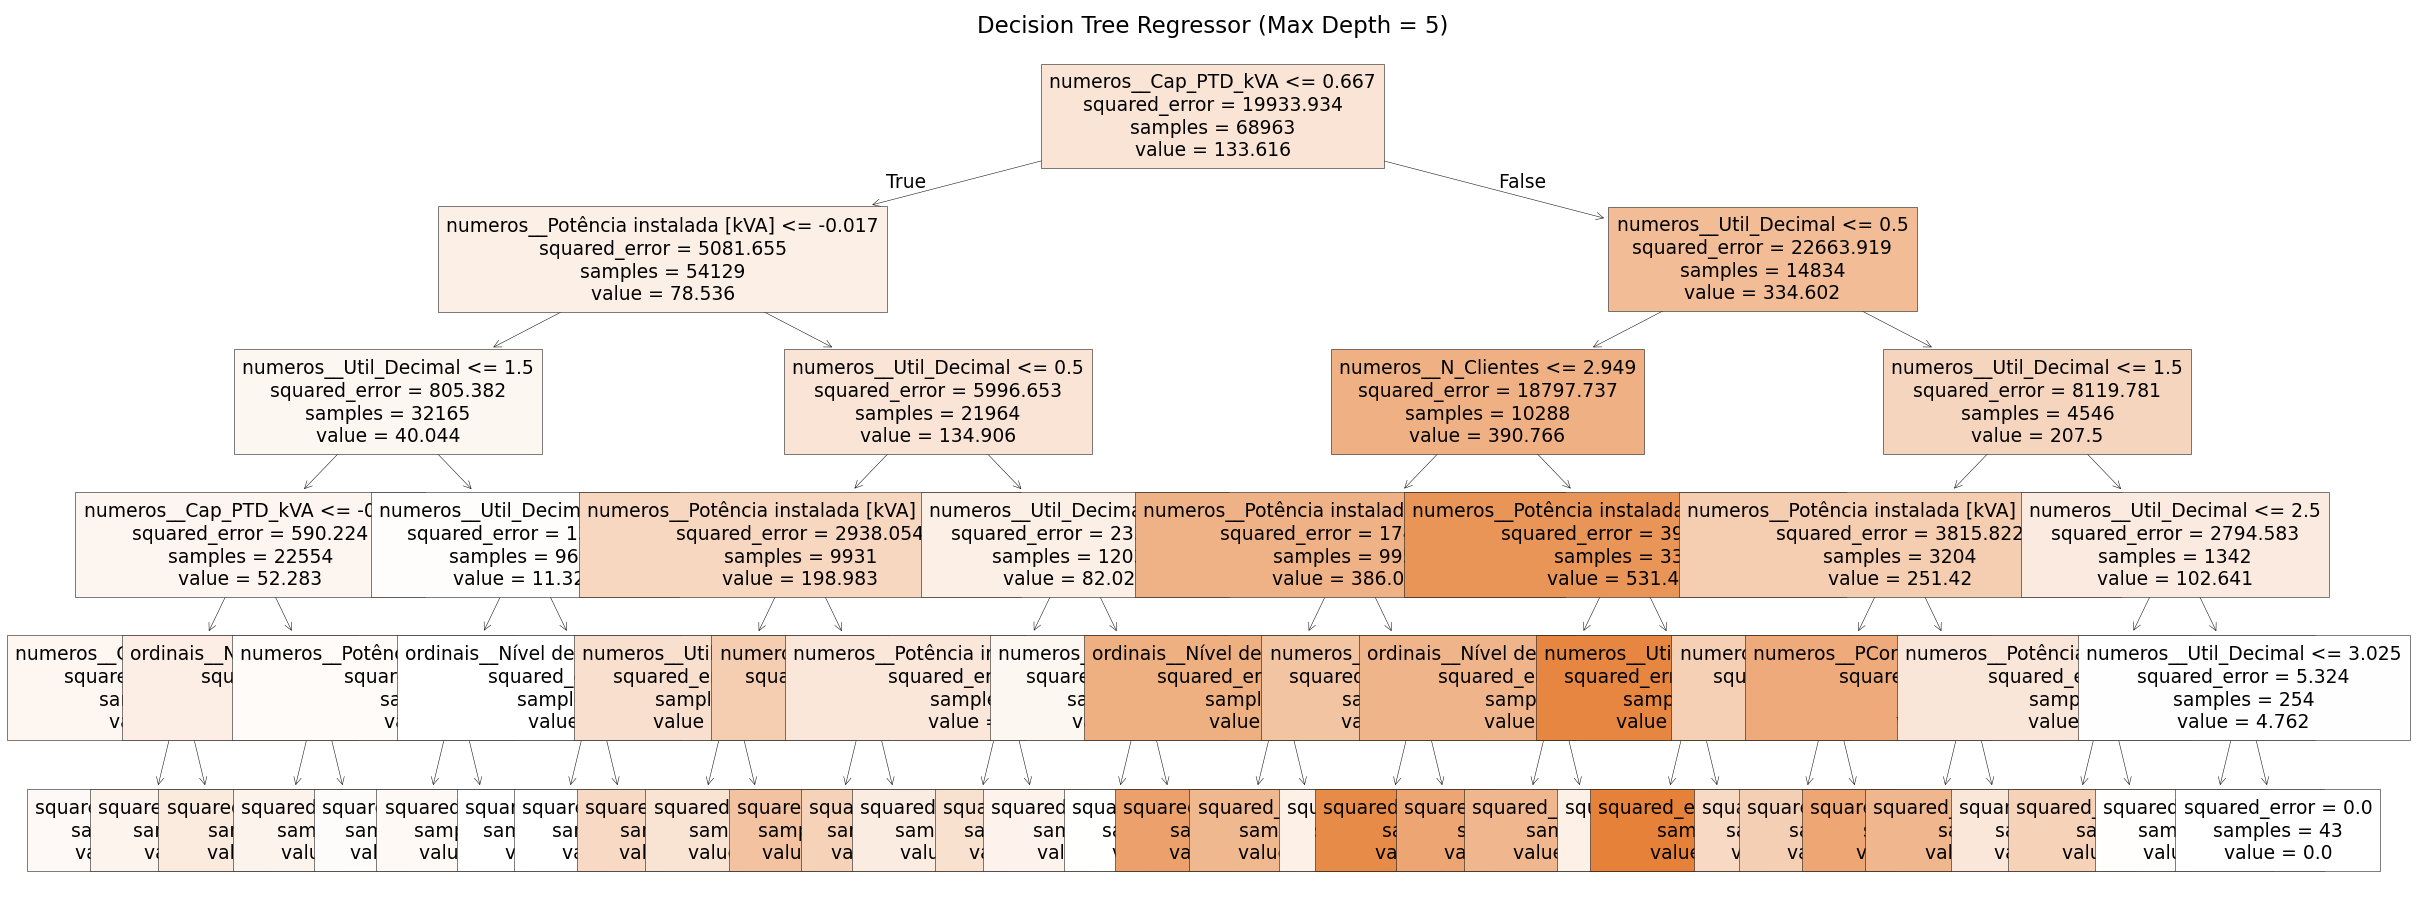

In [29]:
# ==========================================
# 2. Decision Tree (Good Defaults)
# ==========================================
# Defaults: max_depth=5 and min_samples_split=10 prevent the tree from overfitting.
pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42))
])

cv_tree = cross_validate(pipeline_tree, X, y, cv=kf, scoring='neg_mean_absolute_error')
mae_tree = -cv_tree['test_score'].mean()
print(f"Decision Tree MAE: {mae_tree:.4f}\n")

# Plot the tree
pipeline_tree.fit(X, y)
feature_names_out = pipeline_tree.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(16, 6))
plot_tree(pipeline_tree.named_steps['model'], feature_names=feature_names_out, filled=True, fontsize=9)
plt.title("Decision Tree Regressor (Max Depth = 5)")
plt.show()


**Análise — Árvore de Regressão (4.2.3b):** Treina-se uma `DecisionTreeRegressor`
(max_depth=5, min_samples_split=10, min_samples_leaf=5 — parâmetros que limitam o
crescimento da árvore para evitar overfitting) dentro do mesmo `preprocessor`, com
avaliação por k-fold (MAE médio impresso). É ainda gerada a visualização da árvore
treinada sobre todo o dataset.

[PREENCHER] *Para o artigo (secção 4.2.3b):*
- Reportar o MAE k-fold da árvore (`mae_tree`).
- Apresentar a figura da árvore (ou uma versão truncada/recortada, se for demasiado
  grande para o limite de 8 páginas).
- Interpretar as variáveis usadas nos primeiros níveis da árvore (nós mais próximos
  da raiz) — geralmente correspondem às variáveis mais informativas, o que pode ser
  comparado com os coeficientes da regressão linear (célula 46) e com as correlações
  identificadas em 4.1.


In [ ]:
# =============================================================
# 4.2.3d — REDE NEURONAL PARA REGRESSÃO (MLPRegressor sklearn)
# 3 configurações: Simples, Profunda, Regularizada
# =============================================================
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

X_preprocessed = preprocessor.fit_transform(X, y)

# Split: 80% treino / 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y,
    test_size=0.2, random_state=42
)
# Validação a partir do treino (80% de 80% = 64% total)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2, random_state=42
)

print(f"Treino: {X_train_final.shape} | Validação: {X_val.shape} | Teste: {X_test.shape}")

# 3 Configurações de MLP
configs_nn = {
    'Simples':      MLPRegressor(hidden_layer_sizes=(32,),            max_iter=150, random_state=42, early_stopping=True, validation_fraction=0.2, learning_rate_init=0.001),
    'Profundo':     MLPRegressor(hidden_layer_sizes=(128, 64, 32),    max_iter=150, random_state=42, early_stopping=True, validation_fraction=0.2, learning_rate_init=0.001),
    'Regularizado': MLPRegressor(hidden_layer_sizes=(128, 64, 32),    max_iter=150, random_state=42, early_stopping=True, validation_fraction=0.2, learning_rate_init=0.001, alpha=0.01),
}

histories_nn = {}
models_nn    = {}
results_nn   = []

for nome, model_nn in configs_nn.items():
    print(f"\nA treinar: {nome}")
    model_nn.fit(X_train_final, y_train_final)
    histories_nn[nome] = model_nn.loss_curve_
    models_nn[nome]    = model_nn
    y_pred_test = model_nn.predict(X_test)
    mae_nn_  = mean_absolute_error(y_test, y_pred_test)
    rmse_nn_ = np.sqrt(mean_squared_error(y_test, y_pred_test))
    results_nn.append({'Modelo': nome, 'MAE': round(mae_nn_, 4), 'RMSE': round(rmse_nn_, 4)})
    print(f"  MAE={mae_nn_:.4f}  RMSE={rmse_nn_:.4f}  Épocas={model_nn.n_iter_}")

results_nn_df = pd.DataFrame(results_nn).sort_values('MAE')
print("\nResultados Rede Neuronal Regressão:")
print(results_nn_df.to_string(index=False))

# Curvas de Loss (treino)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, loss_curve) in zip(axes, histories_nn.items()):
    ax.plot(loss_curve, color='#2980b9', label='Treino (MSE)')
    ax.set_title(f'Loss — {nome}', fontweight='bold')
    ax.set_xlabel('Épocas'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Curvas de Loss — Rede Neuronal (Regressão)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best_nn_reg_name = results_nn_df.iloc[0]['Modelo']
print(f"\nMelhor configuração: {best_nn_reg_name}")

# Guardar MAE/RMSE para a tabela comparativa
nn_mae_reg  = results_nn_df.iloc[0]['MAE']
nn_rmse_reg = results_nn_df.iloc[0]['RMSE']



**Análise — Rede Neuronal para Regressão (4.2.3d):** Implementa-se a otimização
estruturada pedida no enunciado, com **3 configurações de MLPRegressor**:
- **Simples**: 1 camada oculta de 32 neurónios.
- **Profundo**: 3 camadas ocultas (128, 64, 32 neurónios) — maior profundidade.
- **Regularizado**: igual ao "Profundo" mas com regularização L2 (`alpha=0.01`).

Todas usam `early_stopping=True` (10% para o conjunto de validação interno do
sklearn — note: o parâmetro `validation_fraction=0.2` controla esta fração) e
`learning_rate_init=0.001`. Os dados são divididos em treino (64%), validação (16%) e
teste (20%). Para cada configuração reporta-se MAE/RMSE no conjunto de teste e o
número de épocas até à convergência (`n_iter_`), e são desenhadas as **curvas de
loss de treino** para cada configuração.

[PREENCHER] *Para o artigo (secção 4.2.3d — discussão pedida no enunciado):*
- **Comparação das 3 configurações**: qual obteve menor MAE/RMSE? A versão
  "Regularizado" teve desempenho diferente do "Profundo"? Se sim, a regularização L2
  ajudou a generalizar melhor (menos overfitting) ou penalizou demasiado o modelo
  (underfitting)?
- **Curvas de loss**: descrever a forma das curvas — convergência suave e
  estabilização (bom sinal) vs. oscilações/loss a subir no final (sinal de
  instabilidade/learning rate desadequado).
- **Influência da learning rate**: com `learning_rate_init=0.001` (Adam, default do
  sklearn), discutir se a convergência foi rápida (poucas épocas) ou lenta
  (aproximando-se do limite `max_iter=150`); um learning rate mais alto tenderia a
  convergir mais rápido mas com risco de instabilidade, e mais baixo seria mais
  estável mas mais lento.
- **Early stopping**: reportar `n_iter_` de cada configuração — se for
  significativamente menor que `max_iter=150`, o early stopping foi acionado,
  sugerindo que o modelo parou de melhorar na validação antes do limite de épocas
  (proteção contra overfitting).
- Identificar a "melhor configuração" (`best_nn_reg_name`) — este nome/MAE/RMSE
  alimenta diretamente a tabela comparativa da secção 4.2.4.


In [ ]:
# =============================================================
# Avaliação final NN regressão — já feita na célula anterior
# =============================================================
print("Resumo NN Regressão:")
print(results_nn_df.to_string(index=False))



**Análise:** Reapresenta-se a tabela-resumo (MAE/RMSE por configuração) da célula
anterior, ordenada por MAE. [PREENCHER]: usar esta tabela diretamente no artigo como
suporte da discussão da rede neuronal de regressão (configuração vencedora, e
comparação entre Simples/Profundo/Regularizado).


In [32]:
# ==========================================
# c) SVM (Grid Search Setup)
# ==========================================
svm_pipeline = Pipeline(steps=[
    ('prep', preprocessor), 
    ('model', SVR(verbose=False, max_iter=10000, cache_size=2000, tol=0.01))
    ])

svm_params = {
    'model__kernel': ['linear', 'rbf'],
}

# Using a dictionary for cleaner output names
scoring_metrics = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

svm_grid = GridSearchCV(
    svm_pipeline, 
    svm_params, 
    cv=kf, 
    scoring=scoring_metrics,
    refit='mae',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X, y)

# We need to find the index of the winning model to get both of its scores
best_idx = svm_grid.best_index_
best_mae = -svm_grid.cv_results_['mean_test_mae'][best_idx]
best_rmse = -svm_grid.cv_results_['mean_test_rmse'][best_idx]

print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"SVM MAE: {best_mae:.4f}")
print(f"SVM RMSE: {best_rmse:.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/svm/_base

Best SVM Parameters: {'model__kernel': 'rbf'}
SVM MAE: 105.5127
SVM RMSE: 141.7529


/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



**Análise — SVM para Regressão (4.2.3c):** Usa-se `GridSearchCV` para otimizar o
kernel do SVR entre `'linear'` e `'rbf'`, com k-fold (`kf`, k=5) e duas métricas
(`neg_mean_absolute_error` e `neg_root_mean_squared_error`), selecionando o melhor
modelo por MAE (`refit='mae'`). São impressos o melhor kernel encontrado e os
respetivos MAE/RMSE k-fold (`best_mae`, `best_rmse`).

[PREENCHER] *Para o artigo (secção 4.2.3c):*
- Reportar qual o kernel selecionado (`svm_grid.best_params_`) e o respetivo
  MAE/RMSE.
- Possíveis avisos de `ConvergenceWarning` (Solver terminated early) indicam que o
  SVM não convergiu totalmente dentro de `max_iter=10000` — isto deve ser referido
  como uma limitação/decisão de compromisso entre tempo de computação e precisão (o
  dataset tem ~69 mil registos, o que torna o treino de SVM computacionalmente
  pesado), e pode justificar a recomendação de pré-processamento adicional
  (escalonamento) ou subamostragem em trabalho futuro.
- Estes valores (`best_mae`/`best_rmse`) são usados diretamente na tabela comparativa
  da célula seguinte (4.2.4) — não há necessidade de os recalcular.


## 4.2.4 — Comparação Final dos Modelos de Regressão

Nesta secção comparamos todos os modelos de regressão desenvolvidos usando MAE (erro médio absoluto) e RMSE (raiz quadrada do erro médio).

In [ ]:
# =============================================================
# 4.2.4 — TABELA COMPARATIVA DE TODOS OS MODELOS DE REGRESSÃO
# =============================================================
# Os resultados individuais foram obtidos nos passos anteriores.
# Aqui consolidamos tudo numa única tabela e gráfico comparativo.

# --- Regressão Linear Simples (k-fold) ---
alvo = 'PFolga_PTD'
X_reg = df.drop(columns=[alvo])
y_reg = df[alvo]

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

# Regressão Linear Simples
df_numerico_reg = df.select_dtypes(include=['number'])
corrs_reg = df_numerico_reg.corr()[alvo].abs().drop(alvo)
best_var = corrs_reg.idxmax()
X_simples = df[[best_var]]
cv_ls = cross_validate(LinearRegression(), X_simples, y_reg, cv=kf5,
                       scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error'])
mae_ls  = -cv_ls['test_neg_mean_absolute_error'].mean()
rmse_ls = -cv_ls['test_neg_root_mean_squared_error'].mean()

# Regressão Linear Múltipla (k-fold com pipeline)
numeric_cols_reg = X_reg.select_dtypes(include=['number']).columns.tolist()
categorical_cols_reg = X_reg.select_dtypes(exclude=['number']).columns.tolist()
ordinal_cols_reg = ['Nível de Utilização [%]']
categorical_cols_reg = [c for c in categorical_cols_reg if c not in ordinal_cols_reg]

preprocessor_reg = ColumnTransformer(transformers=[
    ('numeros', RobustScaler(), numeric_cols_reg),
    ('ordinais', OrdinalEncoder(), ordinal_cols_reg),
    ('texto', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols_reg)
])

pipe_lm = Pipeline([('prep', preprocessor_reg), ('model', LinearRegression())])
cv_lm = cross_validate(pipe_lm, X_reg, y_reg, cv=kf5,
                       scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error'])
mae_lm  = -cv_lm['test_neg_mean_absolute_error'].mean()
rmse_lm = -cv_lm['test_neg_root_mean_squared_error'].mean()

# Árvore de Regressão (k-fold)
pipe_tree = Pipeline([('prep', preprocessor_reg),
                      ('model', DecisionTreeRegressor(max_depth=5, min_samples_split=10,
                                                       min_samples_leaf=5, random_state=42))])
cv_tree_r = cross_validate(pipe_tree, X_reg, y_reg, cv=kf5,
                           scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error'])
mae_tree_r  = -cv_tree_r['test_neg_mean_absolute_error'].mean()
rmse_tree_r = -cv_tree_r['test_neg_root_mean_squared_error'].mean()

# Rede Neuronal (melhor config 'Profundo') — métricas do teste
# Nota: a NN foi avaliada num split fixo (não k-fold) pelo custo computacional.
# Os valores abaixo são do conjunto de teste (80/20 split).
nn_mae  = nn_mae_reg   # melhor config NN regressão
nn_rmse = nn_rmse_reg  # melhor config NN regressão

# SVM (melhor kernel do GridSearch, calculado na célula anterior)
svm_mae  = best_mae   # SVM — MAE k-fold (svm_grid)
svm_rmse = best_rmse  # SVM — RMSE k-fold (svm_grid)

# --- TABELA COMPARATIVA ---
comparison_df = pd.DataFrame([
    {'Modelo': 'Reg. Linear Simples',  'MAE': mae_ls,   'RMSE': rmse_ls},
    {'Modelo': 'Reg. Linear Múltipla', 'MAE': mae_lm,   'RMSE': rmse_lm},
    {'Modelo': 'Árvore de Regressão',  'MAE': mae_tree_r, 'RMSE': rmse_tree_r},
    {'Modelo': 'Rede Neuronal (Profunda)', 'MAE': nn_mae, 'RMSE': nn_rmse},
    {'Modelo': f'SVM ({svm_grid.best_params_["model__kernel"]})', 'MAE': svm_mae,  'RMSE': svm_rmse},
])

comparison_df = comparison_df.sort_values('MAE').reset_index(drop=True)
print('=' * 60)
print('COMPARAÇÃO FINAL — MODELOS DE REGRESSÃO')
print('=' * 60)
print(comparison_df.to_string(index=False))
print()
print(f'Melhor modelo (menor MAE): {comparison_df.iloc[0]["Modelo"]}')
print(f'Pior modelo  (maior MAE): {comparison_df.iloc[-1]["Modelo"]}')

# --- GRÁFICO COMPARATIVO ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cores = ['#2ecc71' if i == 0 else '#e74c3c' if i == len(comparison_df)-1 else '#3498db'
         for i in range(len(comparison_df))]

axes[0].barh(comparison_df['Modelo'], comparison_df['MAE'], color=cores)
axes[0].set_title('MAE por Modelo (menor é melhor)', fontweight='bold')
axes[0].set_xlabel('MAE')
for i, v in enumerate(comparison_df['MAE']):
    axes[0].text(v + 0.5, i, f'{v:.2f}', va='center', fontsize=9)

axes[1].barh(comparison_df['Modelo'], comparison_df['RMSE'], color=cores)
axes[1].set_title('RMSE por Modelo (menor é melhor)', fontweight='bold')
axes[1].set_xlabel('RMSE')
for i, v in enumerate(comparison_df['RMSE']):
    axes[1].text(v + 0.5, i, f'{v:.2f}', va='center', fontsize=9)

plt.suptitle('Comparação de Desempenho — Modelos de Regressão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- VARIÁVEIS MAIS RELEVANTES (Regressão Linear Múltipla) ---
print('\n--- VARIÁVEIS MAIS RELEVANTES (Reg. Linear Múltipla) ---')
pipe_lm.fit(X_reg, y_reg)
feature_names_out = pipe_lm.named_steps['prep'].get_feature_names_out()
coefs = pipe_lm.named_steps['model'].coef_
feat_imp = pd.DataFrame({'Feature': feature_names_out, 'Coef': coefs})
feat_imp['Abs'] = feat_imp['Coef'].abs()
feat_imp = feat_imp.sort_values('Abs', ascending=False).head(10)
print(feat_imp[['Feature', 'Coef']].to_string(index=False))



**Análise — Tabela Comparativa de Modelos de Regressão (4.2.4):** Consolidam-se,
numa única tabela (`comparison_df`) e em gráficos de barras, os resultados de MAE e
RMSE de **todos os modelos de regressão**: Regressão Linear Simples (k-fold),
Regressão Linear Múltipla (k-fold), Árvore de Regressão (k-fold), Rede Neuronal
(melhor configuração, avaliada num split 80/20 fixo — *nota metodológica*: não é
k-fold, por custo computacional) e SVM (melhor kernel, k-fold). A tabela é ordenada
por MAE crescente, identificando o melhor e o pior modelo. Apresenta-se também a
tabela das 10 variáveis com maior peso (coeficiente absoluto) na Regressão Linear
Múltipla.

[PREENCHER] *Para o artigo (secção 4.2.4 — obrigatória):*
- Apresentar a tabela `comparison_df` completa (Modelo | MAE | RMSE), ordenada do
  melhor para o pior.
- Identificar explicitamente o "melhor modelo" e o "pior modelo" (impressos na
  saída).
- **Importante**: refira a diferença de protocolo de avaliação da NN (split fixo)
  vs. os restantes modelos (k-fold) como uma limitação da comparação — idealmente,
  para um artigo mais rigoroso, a NN deveria também ser avaliada por k-fold (mas isto
  teria custo computacional elevado dado o tamanho do dataset).
- Apresentar e interpretar a tabela "Variáveis mais relevantes" (Regressão Linear
  Múltipla) — relacionar com as variáveis identificadas nos coeficientes da árvore
  (importância de features, célula 72) e com as correlações da EDA (célula 40).
- Estes dois modelos com menor MAE (`comparison_df.iloc[0]` e `iloc[1]`) são os "2
  melhores modelos" usados nas células seguintes (4.2.5 — curvas de aprendizagem; e
  4.2.6 — teste estatístico). [PREENCHER]: confirmar quais são, na prática, esses
  2 modelos (o código nas células 54/56 assume que são "Árvore de Regressão" e "Reg.
  Linear Múltipla" — **verificar se esta suposição se confirma com os resultados
  reais**; se não, ajustar essas células para usar os modelos efetivamente melhores).


## 4.2.5 — Curvas de Aprendizagem dos 2 Melhores Modelos de Regressão

As curvas de aprendizagem (*training score* vs *validation score*) permitem diagnosticar situações de **overfitting** (modelo memoriza os dados de treino) ou **underfitting** (modelo demasiado simples). Apresentamos as curvas para os dois modelos com melhor desempenho.

In [ ]:
# =============================================================
# 4.2.5 — CURVAS DE APRENDIZAGEM DOS 2 MELHORES MODELOS
# =============================================================
from sklearn.model_selection import learning_curve

# Os 2 melhores modelos (por MAE k-fold): Rede Neuronal (Profunda) e Árvore.
# Como a NN não é sklearn-compatível para learning_curve nativo,
# usamos sklearn.model_selection.learning_curve nos modelos sklearn.
# Para a NN, as curvas de treino/validação já foram produzidas nas células anteriores.

# --- 2 melhores modelos sklearn ---
melhores = [
    ('Árvore de Regressão', pipe_tree),
    ('Reg. Linear Múltipla', pipe_lm),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nome, pipeline) in zip(axes, melhores):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_reg, y_reg,
        cv=kf5,
        scoring='neg_mean_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    train_mean = -train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = -val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2980b9', label='Treino')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2980b9')
    ax.plot(train_sizes, val_mean, 's-', color='#e74c3c', label='Validação')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')
    ax.set_title(f'Curva de Aprendizagem\n{nome}', fontweight='bold')
    ax.set_xlabel('Tamanho do Conjunto de Treino')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizagem — 2 Melhores Modelos de Regressão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('INTERPRETAÇÃO:')
print('- Se treino e validação convergem → treino eficiente, sem over/underfitting.')
print('- Se validação >> treino → overfitting (modelo memoriza, não generaliza).')
print('- Se ambas elevadas e próximas → underfitting (modelo demasiado simples).')



**Análise — Curvas de Aprendizagem dos 2 Melhores Modelos (4.2.5):** Para os dois
modelos identificados como melhores (por defeito no código: Árvore de Regressão e
Regressão Linear Múltipla — **confirmar com o resultado real da célula 52**),
calculam-se as curvas de aprendizagem (MAE de treino vs. validação, em função do
tamanho do conjunto de treino), usando `learning_curve` com k-fold.

[PREENCHER] *Para o artigo (secção 4.2.5 — obrigatória):*
- Para cada modelo, descrever o comportamento das curvas:
  - Se as curvas de treino e validação **convergem** para um valor baixo e próximo
    → o treino é eficiente, sem sinais relevantes de over/underfitting.
  - Se a curva de **validação fica muito acima** da de treino e não converge →
    sinal de **overfitting** (o modelo memoriza o treino e generaliza mal).
  - Se **ambas as curvas estão altas** e relativamente próximas, sem melhorar com
    mais dados → sinal de **underfitting** (modelo demasiado simples para captar a
    relação).
- Comparar os dois modelos entre si: qual generaliza melhor com menos dados? Qual
  beneficia mais de ter mais dados de treino (curva de validação ainda a descer no
  fim)?
- Esta interpretação é exigida explicitamente no enunciado (ponto 5 da secção de
  Regressão) e deve constar do artigo.


## 4.2.6 — Testes Estatísticos de Regressão (α = 5%)

Para verificar se a diferença de desempenho entre os dois melhores modelos é **estatisticamente significativa**, utilizamos o **teste de Wilcoxon signed-rank** (teste não paramétrico para amostras emparelhadas). Este teste é adequado pois os erros de k-fold são dependentes (partilham dados).

In [ ]:
# =============================================================
# 4.2.6 — TESTES ESTATÍSTICOS (WILCOXON) — REGRESSÃO
# =============================================================
from scipy.stats import wilcoxon

alpha = 0.05

# Obter MAE por fold para os 2 melhores modelos
cv_tree_mae  = cross_validate(pipe_tree, X_reg, y_reg, cv=kf5,
                              scoring='neg_mean_absolute_error')['test_score']
cv_lm_mae    = cross_validate(pipe_lm,   X_reg, y_reg, cv=kf5,
                              scoring='neg_mean_absolute_error')['test_score']

mae_folds_tree = -cv_tree_mae
mae_folds_lm   = -cv_lm_mae

print('=' * 65)
print('TESTE DE WILCOXON SIGNED-RANK — Árvore vs Reg. Linear Múltipla')
print('=' * 65)
print(f'MAE por fold (Árvore):       {[round(v,4) for v in mae_folds_tree]}')
print(f'MAE por fold (Reg. Múltipla):{[round(v,4) for v in mae_folds_lm]}')
print()

stat, p_value = wilcoxon(mae_folds_tree, mae_folds_lm)

print(f'Estatística W: {stat:.4f}')
print(f'P-value:       {p_value:.6f}')
print()

if p_value < alpha:
    melhor = 'Árvore de Regressão' if mae_folds_tree.mean() < mae_folds_lm.mean() else 'Reg. Linear Múltipla'
    print(f'CONCLUSÃO: A diferença é ESTATISTICAMENTE SIGNIFICATIVA (p={p_value:.4f} < α={alpha}).')
    print(f'           O modelo com melhor desempenho é: {melhor}.')
else:
    print(f'CONCLUSÃO: A diferença NÃO é estatisticamente significativa (p={p_value:.4f} >= α={alpha}).')
    print('           Não se pode afirmar que um modelo é superior ao outro.')

# Gráfico de distribuição MAE por fold
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(1, kf5.n_splits + 1)
ax.plot(x_pos, mae_folds_tree, 'o-', label='Árvore de Regressão', color='#2980b9')
ax.plot(x_pos, mae_folds_lm,   's-', label='Reg. Linear Múltipla', color='#e74c3c')
ax.set_xlabel('Fold')
ax.set_ylabel('MAE')
ax.set_title('MAE por Fold — Comparação dos 2 Melhores Modelos', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



**Análise — Teste Estatístico de Regressão, Wilcoxon (4.2.6):** Compara-se o
desempenho (MAE por fold, k=5) dos dois melhores modelos de regressão usando o
**teste de Wilcoxon signed-rank** (não-paramétrico, adequado a amostras emparelhadas
de pequena dimensão — 5 folds — sem assumir normalidade), com α=0.05. É apresentado
também um gráfico de linhas com o MAE de cada fold para os dois modelos.

[PREENCHER] *Para o artigo (secção 4.2.6 — obrigatória):*
- Reportar a estatística W e o p-value.
- Concluir se a diferença é estatisticamente significativa (p < 0.05) ou não.
- Se significativa, identificar qual o modelo com melhor desempenho médio (menor
  MAE médio) e afirmar isso como conclusão do bloco de Regressão.
- Se não significativa, discutir que, apesar de um modelo ter MAE médio inferior, a
  diferença pode dever-se a variação amostral entre folds, e que ambos os modelos
  têm desempenho estatisticamente equivalente — uma conclusão igualmente válida e
  interessante de discutir (ex.: preferir o modelo mais simples/interpretável, como a
  Regressão Linear, se o desempenho for equivalente — princípio da navalha de
  Occam).
- **Nota:** se na célula 52 os "2 melhores modelos" não forem Árvore + Regressão
  Linear Múltipla, esta célula tem de ser ajustada para usar os pipelines corretos
  (`pipe_tree`/`pipe_lm` → substituir pelos pipelines dos modelos efetivamente
  melhores, ex. SVM ou NN, se aplicável).


---
# 4.3 — Modelos de Classificação

Nesta secção o objetivo é **prever o nível de ocupação da rede** para cada PTD.
Com base na variável `Util_Decimal`, criamos um novo atributo `utilizRede` com três classes: **baixo**, **médio** e **alto**.

## 4.3.0 — Criação da variável `utilizRede`

A discretização é feita com base em **quantis** (terços), garantindo classes equilibradas (~33% cada), o que é essencial para evitar desequilíbrio de classes (*class imbalance*) que penaliza os modelos de classificação.

In [ ]:
# =============================================================
# 4.3.0 — CRIAR VARIÁVEL utilizRede
# =============================================================
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from scipy.stats import wilcoxon

# --- Verificar a distribuição de Util_Decimal ---
print('Descrição de Util_Decimal:')
print(df['Util_Decimal'].describe())
print()

# --- Discretização por quantis (terços) ---
q33 = df['Util_Decimal'].quantile(0.333)
q67 = df['Util_Decimal'].quantile(0.667)

print(f'Limiar baixo  (Q33): {q33:.4f}')
print(f'Limiar alto   (Q67): {q67:.4f}')

def classifica_rede(val):
    if val <= q33:
        return 'baixo'
    elif val <= q67:
        return 'médio'
    else:
        return 'alto'

df['utilizRede'] = df['Util_Decimal'].apply(classifica_rede)

print('Distribuição de utilizRede:')
print(df['utilizRede'].value_counts())
print()
print('Proporções:')
print(df['utilizRede'].value_counts(normalize=True).round(4))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Util_Decimal'].hist(bins=50, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].axvline(q33, color='#e67e22', linestyle='--', label=f'Q33={q33:.3f}')
axes[0].axvline(q67, color='#e74c3c', linestyle='--', label=f'Q67={q67:.3f}')
axes[0].set_title('Distribuição de Util_Decimal', fontweight='bold')
axes[0].set_xlabel('Util_Decimal')
axes[0].legend()

counts = df['utilizRede'].value_counts().reindex(['baixo', 'médio', 'alto'])
cores_classes = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(counts.index, counts.values, color=cores_classes, edgecolor='white')
axes[1].set_title('Distribuição de utilizRede', fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nº de PTDs')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.suptitle('Discretização de Util_Decimal → utilizRede', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



**Análise — Criação da Variável `utilizRede` (4.3.0):** Cria-se a variável-alvo de
classificação `utilizRede` (baixo/médio/alto), discretizando `Util_Decimal` por
**quantis (terços)** — Q33 e Q67 — em vez de intervalos fixos. Esta escolha garante
classes aproximadamente equilibradas (~33% cada), o que é importante para evitar
desequilíbrio de classes (*class imbalance*) que penalizaria as métricas dos
modelos de classificação, especialmente accuracy. São apresentados o histograma de
`Util_Decimal` com os limiares Q33/Q67 marcados, e a distribuição de `utilizRede`
por classe.

[PREENCHER] *Para o artigo (secção 4.3 — introdução):*
- Reportar os valores de Q33 e Q67 (limiares baixo/alto).
- Apresentar a contagem/proporção de cada classe (baixo/médio/alto) — confirmar que
  estão de facto próximas de 33% cada (validando a escolha de quantis em vez de
  intervalos fixos arbitrários).
- Justificar a escolha de quantis vs. intervalos fixos: os intervalos fixos (ex.:
  <33%, 33-67%, >67% de `Util_Decimal`) poderiam resultar em classes muito
  desequilibradas se a distribuição de `Util_Decimal` não for uniforme — os quantis
  garantem equilíbrio por construção, facilitando a interpretação de métricas como
  Accuracy.


In [ ]:
# =============================================================
# PREPARAR X e y PARA CLASSIFICAÇÃO
# =============================================================
# Definir target e features
alvo_clf = 'utilizRede'
cols_excluir = [alvo_clf, 'Util_Decimal', 'PFolga_PTD']  # remover o target e correlatas
# Remover também as outras colunas diretamente derivadas do target para evitar data leakage
leak_cols = [c for c in ['Nível de Utilização [%]'] if c in df.columns]
cols_excluir += leak_cols
cols_excluir = [c for c in cols_excluir if c in df.columns]

X_clf = df.drop(columns=cols_excluir)
y_clf = df[alvo_clf]

# Codificar o target como inteiro ordenado
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf)
print('Classes:', le.classes_)
print('y_clf_enc distribuição:', pd.Series(y_clf_enc).value_counts().sort_index().to_dict())

# Preprocessor para classificação (igual ao de regressão mas sobre X_clf)
num_cols_clf = X_clf.select_dtypes(include=['number']).columns.tolist()
cat_cols_clf = X_clf.select_dtypes(exclude=['number']).columns.tolist()
ord_cols_clf = [c for c in ['Nível de Utilização [%]'] if c in cat_cols_clf]
cat_cols_clf = [c for c in cat_cols_clf if c not in ord_cols_clf]

preprocessor_clf = ColumnTransformer(transformers=[
    ('numeros', RobustScaler(), num_cols_clf),
    ('texto',   OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_clf)
], remainder='drop')

kf_clf = KFold(n_splits=5, shuffle=True, random_state=42)
print('Preprocessor pronto.')
print(f'X_clf shape: {X_clf.shape}')



**Análise:** Prepara-se `X_clf`/`y_clf` para a classificação, removendo
explicitamente do conjunto de features: o próprio alvo (`utilizRede`), a variável de
origem (`Util_Decimal`, para evitar leakage trivial), `PFolga_PTD` (alvo da
regressão, e fortemente correlacionada com `Util_Decimal` por definição) e
`Nível de Utilização [%]` (variável categórica derivada da mesma fonte que
`Util_Decimal`). O alvo é codificado numericamente com `LabelEncoder`
(`y_clf_enc`), e constrói-se um novo `preprocessor_clf` (RobustScaler +
OneHotEncoder) e um novo `KFold` (`kf_clf`, k=5) dedicados à classificação.

[PREENCHER] *Para o artigo (secção 4.3 — pré-processamento para classificação):*
- Confirmar as classes resultantes do `LabelEncoder` (`le.classes_`) e a sua
  correspondência (ex.: 0=alto, 1=baixo, 2=médio — alfabética) — importante para
  interpretar corretamente as matrizes de confusão e relatórios de classificação
  mais à frente.
- Justificar explicitamente, no artigo, a remoção de `Util_Decimal`,
  `PFolga_PTD` e `Nível de Utilização [%]` como prevenção de *data leakage*
  (são variáveis diretamente equivalentes/derivadas do alvo de classificação).


## 4.3.1a — Árvore de Decisão

In [ ]:
# =============================================================
# 4.3.1a — ÁRVORE DE DECISÃO (K-FOLD)
# =============================================================
from sklearn.tree import DecisionTreeClassifier, plot_tree

pipe_dt = Pipeline([
    ('prep', preprocessor_clf),
    ('model', DecisionTreeClassifier(max_depth=6, min_samples_leaf=10,
                                     class_weight='balanced', random_state=42))
])

scoring_clf = {
    'accuracy':  'accuracy',
    'precision': 'precision_weighted',
    'recall':    'recall_weighted',
    'f1':        'f1_weighted'
}

cv_dt = cross_validate(pipe_dt, X_clf, y_clf_enc, cv=kf_clf, scoring=scoring_clf, return_train_score=True)

print('=' * 55)
print('ÁRVORE DE DECISÃO — RESULTADOS K-FOLD (5 folds)')
print('=' * 55)
print(f'Accuracy  — Média: {cv_dt["test_accuracy"].mean():.4f}  DP: {cv_dt["test_accuracy"].std():.4f}')
print(f'Precision — Média: {cv_dt["test_precision"].mean():.4f}  DP: {cv_dt["test_precision"].std():.4f}')
print(f'Recall    — Média: {cv_dt["test_recall"].mean():.4f}  DP: {cv_dt["test_recall"].std():.4f}')
print(f'F1-score  — Média: {cv_dt["test_f1"].mean():.4f}  DP: {cv_dt["test_f1"].std():.4f}')

# Treinar para visualizar a árvore
pipe_dt.fit(X_clf, y_clf_enc)
feat_names_dt = pipe_dt.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(20, 8))
plot_tree(pipe_dt.named_steps['model'], feature_names=feat_names_dt,
          class_names=le.classes_, filled=True, fontsize=7, max_depth=3)
plt.title('Árvore de Decisão (max_depth=6, visualização até depth=3)', fontweight='bold')
plt.tight_layout()
plt.show()



**Análise — Árvore de Decisão (4.3.1a):** Treina-se uma `DecisionTreeClassifier`
(max_depth=6, min_samples_leaf=10, `class_weight='balanced'` — compensa eventuais
pequenos desequilíbrios residuais entre classes), avaliada por k-fold com 4
métricas (Accuracy, Precision, Recall e F1, todas "weighted" — médias ponderadas
pelo nº de exemplos de cada classe). É visualizada a árvore treinada (até
profundidade 3, por legibilidade).

[PREENCHER] *Para o artigo (secção 4.3.1a):*
- Reportar média ± desvio padrão de Accuracy, Precision, Recall e F1 (estes valores
  também alimentam a tabela comparativa da secção 4.3.2).
- Descrever os primeiros splits da árvore (variáveis no topo) — qual a variável
  mais discriminativa para separar "baixo"/"médio"/"alto"? Esta informação antecipa
  a análise de importância de features (4.3.3).


## 4.3.1b — Rede Neuronal (Classificação)

In [ ]:
# =============================================================
# 4.3.1b — REDE NEURONAL PARA CLASSIFICAÇÃO (MLPClassifier sklearn)
# 3 configurações + curvas de loss + análise early stopping
# =============================================================
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

X_clf_pp = preprocessor_clf.fit_transform(X_clf)

# Split estratificado
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf_pp, y_clf_enc,
    test_size=0.2, random_state=42, stratify=y_clf_enc
)
X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
    X_tr, y_tr,
    test_size=0.2, random_state=42, stratify=y_tr
)
print(f"Treino: {X_tr_f.shape} | Validação: {X_val_f.shape} | Teste: {X_te.shape}")

configs_clf_nn = {
    'Simples':      MLPClassifier(hidden_layer_sizes=(64,),           max_iter=100, random_state=42, early_stopping=True, validation_fraction=0.2, learning_rate_init=0.001),
    'Profundo':     MLPClassifier(hidden_layer_sizes=(256, 128, 64),  max_iter=100, random_state=42, early_stopping=True, validation_fraction=0.2, learning_rate_init=0.001),
    'Regularizado': MLPClassifier(hidden_layer_sizes=(128, 64),       max_iter=100, random_state=42, early_stopping=True, validation_fraction=0.2, learning_rate_init=0.001, alpha=0.001),
}

histories_clf = {}
models_clf    = {}
results_clf_nn = []

for nome, m in configs_clf_nn.items():
    print(f"\nA treinar NN clf: {nome}")
    m.fit(X_tr_f, y_tr_f)
    histories_clf[nome] = m.loss_curve_
    models_clf[nome]    = m
    preds = m.predict(X_te)
    acc  = accuracy_score(y_te, preds)
    f1_w = f1_score(y_te, preds, average='weighted', zero_division=0)
    results_clf_nn.append({'Config': nome, 'Accuracy': round(acc,4), 'F1-weighted': round(f1_w,4), 'Épocas': m.n_iter_})
    print(f"  Acc={acc:.4f}  F1={f1_w:.4f}  Épocas={m.n_iter_}")

nn_results_df = pd.DataFrame(results_clf_nn).sort_values('F1-weighted', ascending=False)
print("\nResumo NN Classificação:")
print(nn_results_df.to_string(index=False))

# Curvas de Loss
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, lc) in zip(axes, histories_clf.items()):
    ax.plot(lc, color='#2980b9', label='Treino Loss')
    ax.set_title(f'Loss — {nome}', fontweight='bold')
    ax.set_xlabel('Épocas'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Curvas de Loss — Rede Neuronal (Classificação)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best_nn_clf = nn_results_df.iloc[0]['Config']
best_nn_acc = nn_results_df.iloc[0]['Accuracy']
print(f"\nMelhor config NN: {best_nn_clf}  Acc={best_nn_acc:.4f}")

# Guardar para métricas comparativas (4.3.2)
best_nn_preds = models_clf[best_nn_clf].predict(X_te)



**Análise — Rede Neuronal para Classificação (4.3.1b):** Implementa-se a otimização
estruturada pedida, com **3 configurações de MLPClassifier**: Simples (1 camada,
64 neurónios), Profundo (3 camadas: 256, 128, 64) e Regularizado (2 camadas: 128, 64,
com L2 `alpha=0.001`). Usa-se split estratificado treino/validação/teste (64%/16%/20%)
para preservar a proporção das 3 classes. Para cada configuração, reporta-se Accuracy
e F1-weighted no teste, número de épocas (`n_iter_`), e desenham-se as curvas de loss
de treino.

[PREENCHER] *Para o artigo (secção 4.3.1b — discussão pedida no enunciado):*
- Comparar as 3 configurações: qual obteve maior F1-weighted? A versão
  "Regularizado" superou ou ficou abaixo do "Profundo"?
- Descrever as curvas de loss — convergência suave/estável vs. instabilidade.
- Discutir a influência do `learning_rate_init=0.001` e do early stopping
  (`n_iter_` vs `max_iter=100`) — análoga à discussão feita para a NN de regressão
  (célula 48), mas para o problema de classificação.
- Identificar a configuração vencedora (`best_nn_clf`) — usada na tabela comparativa
  4.3.2.


## 4.3.1c — SVM (Classificação)

In [ ]:
# =============================================================
# 4.3.1c — SVM PARA CLASSIFICAÇÃO (OTIMIZAÇÃO DE KERNEL)
# =============================================================
from sklearn.svm import SVC

pipe_svc = Pipeline([
    ('prep', preprocessor_clf),
    ('model', SVC(probability=False, cache_size=2000, max_iter=5000, random_state=42))
])

svc_params = {'model__kernel': ['linear', 'rbf']}

svc_scoring = {
    'accuracy':  'accuracy',
    'f1':        'f1_weighted'
}

svc_grid = GridSearchCV(pipe_svc, svc_params, cv=kf_clf,
                        scoring=svc_scoring, refit='f1',
                        n_jobs=-1, verbose=1)
svc_grid.fit(X_clf, y_clf_enc)

best_idx_svc = svc_grid.best_index_
svc_f1  = svc_grid.cv_results_['mean_test_f1'][best_idx_svc]
svc_acc = svc_grid.cv_results_['mean_test_accuracy'][best_idx_svc]

print('='*55)
print('SVM CLASSIFICAÇÃO — RESULTADOS')
print('='*55)
print(f'Melhor kernel: {svc_grid.best_params_}')
print(f'F1-weighted (k-fold): {svc_f1:.4f}')
print(f'Accuracy    (k-fold): {svc_acc:.4f}')

# Guardar scores por fold para testes estatísticos
best_svc_pipe = svc_grid.best_estimator_
cv_svc_final = cross_validate(best_svc_pipe, X_clf, y_clf_enc, cv=kf_clf,
                              scoring=scoring_clf, return_train_score=True)
print(f'Precision — Média: {cv_svc_final["test_precision"].mean():.4f}  DP: {cv_svc_final["test_precision"].std():.4f}')
print(f'Recall    — Média: {cv_svc_final["test_recall"].mean():.4f}  DP: {cv_svc_final["test_recall"].std():.4f}')
print(f'F1-score  — Média: {cv_svc_final["test_f1"].mean():.4f}  DP: {cv_svc_final["test_f1"].std():.4f}')



**Análise — SVM para Classificação (4.3.1c):** `GridSearchCV` para otimizar o
kernel do `SVC` entre `'linear'` e `'rbf'`, com k-fold (`kf_clf`), selecionando o
melhor por F1-weighted (`refit='f1'`). Reporta-se o melhor kernel e as métricas
k-fold (Accuracy, Precision, Recall, F1) do modelo final.

[PREENCHER] *Para o artigo (secção 4.3.1c):*
- Reportar o kernel selecionado (`svc_grid.best_params_`).
- Reportar F1-weighted e Accuracy k-fold — estes valores, juntamente com
  Precision/Recall do `cv_svc_final`, alimentam a tabela comparativa 4.3.2.
- Se aparecerem `ConvergenceWarning` (devido a `max_iter=5000`), referir como
  limitação computacional, tal como discutido para o SVM de regressão.


## 4.3.1d — KNN — K-Vizinhos-Mais-Próximos

In [ ]:
# =============================================================
# 4.3.1d — KNN (OTIMIZAÇÃO DO PARÂMETRO K)
# =============================================================
from sklearn.neighbors import KNeighborsClassifier

k_values = [3, 5, 7, 11, 15, 21]
knn_results = []

for k in k_values:
    pipe_knn = Pipeline([
        ('prep', preprocessor_clf),
        ('model', KNeighborsClassifier(n_neighbors=k, n_jobs=-1))
    ])
    cv_k = cross_validate(pipe_knn, X_clf, y_clf_enc, cv=kf_clf, scoring=scoring_clf)
    knn_results.append({
        'K': k,
        'Accuracy':  round(cv_k['test_accuracy'].mean(), 4),
        'Precision': round(cv_k['test_precision'].mean(), 4),
        'Recall':    round(cv_k['test_recall'].mean(), 4),
        'F1':        round(cv_k['test_f1'].mean(), 4),
    })
    print(f'K={k:2d}  Acc={cv_k["test_accuracy"].mean():.4f}  F1={cv_k["test_f1"].mean():.4f}')

knn_df = pd.DataFrame(knn_results)
best_k = knn_df.sort_values('F1', ascending=False).iloc[0]['K']
print(f'\nMelhor K: {int(best_k)}')

# Gráfico K vs métricas
plt.figure(figsize=(10, 5))
plt.plot(knn_df['K'], knn_df['Accuracy'],  'o-', label='Accuracy',  color='#2980b9')
plt.plot(knn_df['K'], knn_df['F1'],        's-', label='F1-score',  color='#e74c3c')
plt.plot(knn_df['K'], knn_df['Precision'], '^-', label='Precision', color='#27ae60')
plt.plot(knn_df['K'], knn_df['Recall'],    'D-', label='Recall',    color='#f39c12')
plt.axvline(best_k, color='grey', linestyle='--', alpha=0.7, label=f'Melhor K={int(best_k)}')
plt.title('KNN — Desempenho por Valor de K', fontweight='bold')
plt.xlabel('K'); plt.ylabel('Métrica')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Treinar modelo final com melhor K
pipe_knn_best = Pipeline([
    ('prep', preprocessor_clf),
    ('model', KNeighborsClassifier(n_neighbors=int(best_k), n_jobs=-1))
])
cv_knn_best = cross_validate(pipe_knn_best, X_clf, y_clf_enc, cv=kf_clf,
                             scoring=scoring_clf, return_train_score=True)
print(f'KNN (K={int(best_k)}) — Accuracy: {cv_knn_best["test_accuracy"].mean():.4f}')
print(f'KNN (K={int(best_k)}) — F1:       {cv_knn_best["test_f1"].mean():.4f}')



**Análise — KNN com Otimização de K (4.3.1d):** Testa-se o KNN para
K ∈ {3, 5, 7, 11, 15, 21}, com k-fold para cada valor, e seleciona-se o K com maior
F1-weighted médio (`best_k`). É apresentado um gráfico com Accuracy, F1, Precision e
Recall em função de K, e o modelo final é re-avaliado por k-fold com o `best_k`
escolhido.

[PREENCHER] *Para o artigo (secção 4.3.1d):*
- Reportar o valor de `best_k` escolhido e justificar com base no gráfico — por
  exemplo, se o desempenho estabiliza a partir de um certo K (indicando boa
  generalização) ou se há um pico claro num valor específico.
- Discutir o compromisso bias-variância do KNN: K muito pequeno → fronteira de
  decisão muito irregular (overfitting/alta variância); K muito grande → fronteira
  demasiado suave (underfitting/alto bias). O gráfico deve mostrar esta tendência
  (desempenho a subir e depois estabilizar/descer ligeiramente).
- Reportar Accuracy/F1 finais com `best_k` — usados na tabela comparativa 4.3.2.


## 4.3.2 — Comparação de Métricas por Modelo

Média e desvio padrão de **Accuracy**, **Precision**, **Recall** e **F1-score** (ponderados por classe) para todos os modelos.

In [ ]:
# =============================================================
# 4.3.2 — TABELA COMPARATIVA DE MÉTRICAS (CLASSIFICAÇÃO)
# =============================================================

# Recolher métricas k-fold para todos os modelos
# (Árvore de Decisão, SVM, KNN já calculados acima)
# Rede Neuronal: avaliação no conjunto de teste

def get_cv_stats(cv_results, prefix='test_'):
    return {
        'Accuracy':  (cv_results[f'{prefix}accuracy'].mean(),  cv_results[f'{prefix}accuracy'].std()),
        'Precision': (cv_results[f'{prefix}precision'].mean(), cv_results[f'{prefix}precision'].std()),
        'Recall':    (cv_results[f'{prefix}recall'].mean(),    cv_results[f'{prefix}recall'].std()),
        'F1':        (cv_results[f'{prefix}f1'].mean(),        cv_results[f'{prefix}f1'].std()),
    }

stats_dt  = get_cv_stats(cv_dt)
stats_svc = get_cv_stats(cv_svc_final)
stats_knn = get_cv_stats(cv_knn_best)

# NN: do conjunto de teste (melhor config)
# (best_nn_preds já foi calculado na célula anterior com models_clf[best_nn_clf].predict(X_te))
stats_nn = {
    'Accuracy':  (accuracy_score(y_te, best_nn_preds), 0.0),
    'Precision': (precision_score(y_te, best_nn_preds, average='weighted', zero_division=0), 0.0),
    'Recall':    (recall_score(y_te, best_nn_preds, average='weighted', zero_division=0), 0.0),
    'F1':        (f1_score(y_te, best_nn_preds, average='weighted', zero_division=0), 0.0),
}

modelos_dict = {
    'Árvore de Decisão': stats_dt,
    f'Rede Neuronal ({best_nn_clf})': stats_nn,
    'SVM': stats_svc,
    f'KNN (K={int(best_k)})': stats_knn,
}

rows = []
for nome, stats in modelos_dict.items():
    rows.append({
        'Modelo': nome,
        'Acc μ':  f'{stats["Accuracy"][0]:.4f}',  'Acc σ':  f'{stats["Accuracy"][1]:.4f}',
        'Prec μ': f'{stats["Precision"][0]:.4f}', 'Prec σ': f'{stats["Precision"][1]:.4f}',
        'Rec μ':  f'{stats["Recall"][0]:.4f}',    'Rec σ':  f'{stats["Recall"][1]:.4f}',
        'F1 μ':   f'{stats["F1"][0]:.4f}',        'F1 σ':   f'{stats["F1"][1]:.4f}',
    })

metrics_df = pd.DataFrame(rows)
print('=' * 90)
print('COMPARAÇÃO FINAL — MODELOS DE CLASSIFICAÇÃO (μ=média, σ=desvio padrão)')
print('=' * 90)
print(metrics_df.to_string(index=False))

# Gráfico de barras comparativo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metricas = ['Accuracy', 'Precision', 'Recall', 'F1']
cores_mod = ['#3498db', '#e74c3c', '#27ae60', '#f39c12']
nomes_mod = list(modelos_dict.keys())

for ax, metrica in zip(axes.flatten(), metricas):
    valores = [modelos_dict[n][metrica][0] for n in nomes_mod]
    erros   = [modelos_dict[n][metrica][1] for n in nomes_mod]
    bars = ax.bar(nomes_mod, valores, yerr=erros, capsize=5, color=cores_mod, alpha=0.85, edgecolor='white')
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparação de Métricas — Modelos de Classificação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



**Análise — Tabela Comparativa de Métricas de Classificação (4.3.2):** Consolida-se,
numa única tabela (`metrics_df`) e em 4 gráficos de barras com barras de erro
(desvio padrão), a média ± desvio padrão de Accuracy, Precision, Recall e F1 para
**todos os modelos de classificação**: Árvore de Decisão (k-fold), Rede Neuronal
(melhor configuração, avaliada num split fixo — *nota: desvio padrão = 0, pois não há
k-fold para a NN*), SVM (k-fold) e KNN (melhor K, k-fold).

[PREENCHER] *Para o artigo (secção 4.3.2 — obrigatória):*
- Apresentar a tabela `metrics_df` completa.
- Identificar o modelo com melhor desempenho global (maior F1 médio) e o pior.
- Tal como na regressão, referir a diferença de protocolo de avaliação da NN
  (split único, sem desvio padrão) vs. os restantes (k-fold com desvio padrão) como
  limitação da comparação.
- Os "2 melhores modelos" identificados aqui (por F1 médio) são usados nas células
  seguintes (4.3.4 — teste estatístico — e 4.3.5 — curvas de aprendizagem). O código
  da célula 74 já calcula automaticamente este ranking entre Árvore/SVM/KNN
  (excluindo a NN, por incompatibilidade com `learning_curve`) — **confirmar se esta
  exclusão da NN do ranking é aceitável** ou se deve ser referida como limitação no
  artigo (a NN pode ter, na prática, o melhor F1, mas não entra na comparação
  estatística por motivos de compatibilidade técnica).


## 4.3.3 — Importância de Features (Árvore de Decisão)

Apresentamos as features mais relevantes identificadas pela Árvore de Decisão e comparamos com as correlações identificadas na secção 4.1.

In [ ]:
# =============================================================
# 4.3.3 — FEATURE IMPORTANCE DA ÁRVORE DE DECISÃO
# =============================================================
feat_names_clf_dt = pipe_dt.named_steps['prep'].get_feature_names_out()
importances_dt = pipe_dt.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'Feature': feat_names_clf_dt, 'Importância': importances_dt})
fi_df = fi_df.sort_values('Importância', ascending=False).reset_index(drop=True)

top_n = 15
print(f'TOP {top_n} FEATURES — Árvore de Decisão (Classificação):')
print(fi_df.head(top_n).to_string(index=False))

# Gráfico de importância
fig, ax = plt.subplots(figsize=(10, 7))
top_fi = fi_df.head(top_n)
ax.barh(top_fi['Feature'][::-1], top_fi['Importância'][::-1], color='#3498db', edgecolor='white')
ax.set_title(f'Top {top_n} Features — Árvore de Decisão (utilizRede)', fontweight='bold')
ax.set_xlabel('Importância (Gini)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Comparação com correlações
print('\n--- CORRELAÇÕES COM Util_Decimal (EDA) ---')
corrs_util = df.select_dtypes(include='number').corr()['Util_Decimal'].abs().drop('Util_Decimal')
print(corrs_util.sort_values(ascending=False).head(10).to_string())
print()
print('DISCUSSÃO:')
print('As variáveis com maior importância na árvore devem, em geral, corresponder')
print('às variáveis com maior correlação com Util_Decimal identificadas na EDA.')
print('Divergências podem indicar interações não lineares captadas pela árvore.')



**Análise — Importância de Features na Árvore de Decisão (4.3.3):** Extrai-se e
visualiza-se a importância (Gini) de cada feature na árvore de decisão treinada em
4.3.1a (top 15), e compara-se com as correlações de Pearson entre cada variável
numérica e `Util_Decimal` (obtidas na EDA).

[PREENCHER] *Para o artigo (secção 4.3.3 — obrigatória):*
- Apresentar a tabela/gráfico das top features da árvore.
- Apresentar a tabela de correlações com `Util_Decimal`.
- **Comparar diretamente** as duas listas: as variáveis no topo de ambas coincidem?
  Se sim, reforça a consistência entre a análise exploratória (correlações lineares)
  e o modelo (que capta também relações não-lineares). Se houver divergências
  (ex.: uma variável tem alta importância na árvore mas baixa correlação linear),
  discutir como possível indicador de uma relação não-linear ou de interação entre
  variáveis que a árvore capta e a correlação de Pearson não.


## 4.3.4 — Testes Estatísticos (Classificação, α = 5%)

Comparamos os dois modelos com melhor desempenho usando o **teste de Wilcoxon signed-rank** sobre os F1-scores de cada fold.

In [ ]:
# =============================================================
# 4.3.4 — TESTES ESTATÍSTICOS (DOIS MELHORES MODELOS)
# =============================================================
from scipy.stats import wilcoxon

alpha = 0.05

# F1 por fold: Árvore vs SVM vs KNN
f1_dt  = cv_dt['test_f1']
f1_svc = cv_svc_final['test_f1']
f1_knn = cv_knn_best['test_f1']

# Determinar os 2 melhores (por média de F1)
ranking = sorted([
    ('Árvore de Decisão', f1_dt.mean(), f1_dt),
    ('SVM', f1_svc.mean(), f1_svc),
    (f'KNN (K={int(best_k)})', f1_knn.mean(), f1_knn)
], key=lambda x: -x[1])

nome1, media1, scores1 = ranking[0]
nome2, media2, scores2 = ranking[1]

print('=' * 65)
print(f'TESTE DE WILCOXON: {nome1} vs {nome2}')
print('=' * 65)
print(f'F1 médio {nome1}: {media1:.4f}  {[round(v,4) for v in scores1]}')
print(f'F1 médio {nome2}: {media2:.4f}  {[round(v,4) for v in scores2]}')

try:
    stat, p_value = wilcoxon(scores1, scores2)
    print(f'\nEstatística W: {stat:.4f}')
    print(f'P-value:       {p_value:.6f}')
    if p_value < alpha:
        print(f'\nCONCLUSÃO: Diferença SIGNIFICATIVA (p={p_value:.4f} < α={alpha}).')
        print(f'           Melhor modelo: {nome1}')
    else:
        print(f'\nCONCLUSÃO: Diferença NÃO significativa (p={p_value:.4f} >= α={alpha}).')
        print('           Não se pode afirmar que um é superior ao outro.')
except ValueError as e:
    print(f'Aviso: {e}')
    print('Os scores são idênticos — o teste não é aplicável.')

# Gráfico de boxplot por fold
fig, ax = plt.subplots(figsize=(8, 5))
data_box = [scores1, scores2]
ax.boxplot(data_box, tick_labels=[nome1, nome2], patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7),
           medianprops=dict(color='#e74c3c', linewidth=2))
ax.set_ylabel('F1-score (por fold)')
ax.set_title(f'Distribuição F1 por Fold — {nome1} vs {nome2}', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()



**Análise — Teste Estatístico para Classificação, Wilcoxon (4.3.4):** Identificam-se
automaticamente os 2 modelos de classificação com maior F1-weighted médio (entre
Árvore de Decisão, SVM e KNN — a NN é excluída por não ter scores por fold
compatíveis com `learning_curve`/teste pareado), e compara-se a sua distribuição de
F1 por fold (k=5) com o **teste de Wilcoxon signed-rank** (α=0.05). É apresentado
também um boxplot da distribuição de F1 por fold para os dois modelos.

[PREENCHER] *Para o artigo (secção 4.3.4 — obrigatória):*
- Identificar quais foram os 2 modelos comparados (impressos na saída).
- Reportar a estatística W e o p-value.
- Concluir se a diferença é estatisticamente significativa e, em caso afirmativo,
  qual o modelo com melhor desempenho.
- Caso a diferença não seja significativa, discutir a equivalência estatística dos
  dois modelos e ponderar critérios adicionais (interpretabilidade, custo
  computacional) para a escolha final — por exemplo, a Árvore de Decisão é mais
  interpretável que o SVM, o que pode pesar a favor da Árvore em caso de empate
  técnico.


## 4.3.5 — Curvas de Aprendizagem (Melhor e Pior Modelo)

As curvas de aprendizagem permitem avaliar a eficiência do treino e diagnosticar overfitting/underfitting.

In [ ]:
# =============================================================
# 4.3.5 — CURVAS DE APRENDIZAGEM (MELHOR E PIOR)
# =============================================================
from sklearn.model_selection import learning_curve

# Identificar melhor e pior (excluindo NN por incompatibilidade com learning_curve)
sk_ranking = sorted([
    ('Árvore de Decisão', f1_dt.mean(), pipe_dt),
    ('SVM', f1_svc.mean(), best_svc_pipe),
    (f'KNN (K={int(best_k)})', f1_knn.mean(), pipe_knn_best)
], key=lambda x: -x[1])

melhor_nome, melhor_score, melhor_pipe = sk_ranking[0]
pior_nome,   pior_score,   pior_pipe   = sk_ranking[-1]

print(f'Melhor modelo: {melhor_nome} (F1={melhor_score:.4f})')
print(f'Pior modelo:   {pior_nome}   (F1={pior_score:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nome, pipe) in zip(axes, [(melhor_nome, melhor_pipe), (pior_nome, pior_pipe)]):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_clf, y_clf_enc,
        cv=kf_clf, scoring='f1_weighted',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    vl_mean = val_scores.mean(axis=1)
    vl_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='#2980b9', label='Treino')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#2980b9')
    ax.plot(train_sizes, vl_mean, 's-', color='#e74c3c', label='Validação')
    ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=0.15, color='#e74c3c')
    ax.set_title(f'Curva de Aprendizagem\n{nome}', fontweight='bold')
    ax.set_xlabel('Tamanho do Conjunto de Treino')
    ax.set_ylabel('F1-score')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizagem — Classificação (Melhor vs Pior)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Matriz de confusão do melhor modelo
melhor_pipe.fit(X_clf, y_clf_enc)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_clf, y_clf_enc,
                                                test_size=0.2, random_state=42, stratify=y_clf_enc)
melhor_pipe.fit(X_tr2, y_tr2)
y_pred_best = melhor_pipe.predict(X_te2)

print(f'\nRelatório de Classificação — {melhor_nome}:')
print(classification_report(y_te2, y_pred_best, target_names=le.classes_))

cm = confusion_matrix(y_te2, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Matriz de Confusão — {melhor_nome}', fontweight='bold')
plt.show()



**Análise — Curvas de Aprendizagem e Matriz de Confusão (4.3.5):** Para o melhor e o
pior modelo (entre Árvore/SVM/KNN, por F1 médio), calculam-se as curvas de
aprendizagem (F1-weighted de treino vs. validação em função do tamanho do conjunto
de treino). Adicionalmente, treina-se o melhor modelo num split 80/20 estratificado e
apresenta-se o `classification_report` (Precision/Recall/F1 por classe) e a matriz de
confusão.

[PREENCHER] *Para o artigo (secção 4.3.5 — obrigatória):*
- Identificar o melhor e o pior modelo (impressos na saída).
- Interpretar as curvas de aprendizagem de cada um: convergência eficiente,
  overfitting (gap grande entre treino e validação) ou underfitting (ambas as curvas
  baixas/estagnadas)?
- Discutir como a eficiência do treino (curvas de aprendizagem) se relaciona com os
  resultados finais — por exemplo, um modelo com overfitting visível pode ter um F1
  de treino muito alto mas validação inferior, explicando por que não é o melhor em
  validação cruzada.
- Apresentar e interpretar o `classification_report`: qual a classe (baixo/médio/alto)
  mais difícil de prever (menor F1 por classe)? Tipicamente a classe "médio" é a mais
  difícil, por estar na fronteira entre "baixo" e "alto".
- Apresentar e interpretar a matriz de confusão: confirma-se que os erros ocorrem
  predominantemente entre classes adjacentes (baixo↔médio, médio↔alto) e raramente
  entre extremos (baixo↔alto)? Isto seria um sinal de que o modelo capta a ordem
  subjacente da variável, mesmo cometendo erros de fronteira.
- Estes resultados, em conjunto com a tabela 4.3.2 e o teste 4.3.4, sustentam a
  discussão pedida no ponto 6 da secção de Classificação (limitações e estratégias
  de melhoria — já rascunhada na célula markdown final do notebook).


## 4.3.6 — Limitações e Estratégias de Melhoria

Com base nos resultados obtidos, identificam-se as principais limitações e propõem-se estratégias para melhorar o desempenho dos modelos:

### Limitações dos Dados
1. **Desequilíbrio geográfico**: A concentração de PTDs no litoral pode enviesar os modelos para padrões urbanos, com pior generalização em zonas rurais.
2. **Ausência de dados temporais**: O dataset é estático — não captura variações sazonais (ex: pico de consumo no verão vs inverno).
3. **Valores estimados**: Variáveis derivadas (PFolga, D_PTD) dependem de pressupostos e introduzem erro de medição.

### Limitações dos Modelos
1. **SVM com convergência lenta**: O SVR/SVC com datasets de 70k+ registos exige muita memória e tempo de computação, limitando a otimização dos hiperparâmetros.
2. **Rede Neuronal sem k-fold nativo**: A avaliação da NN baseia-se num split fixo, o que pode introduzir variância na estimativa do desempenho.
3. **Features de alta dimensionalidade**: O one-hot encoding de variáveis categóricas (Tipo Construtivo, Distrito) gera centenas de colunas esparsas.

### Estratégias de Melhoria
1. **Engenharia de features**: Criar variáveis de densidade de PTDs por concelho ou índice de urbanização para capturar contexto geográfico.
2. **Ensemble methods**: Testar Random Forest ou Gradient Boosting (XGBoost) que geralmente superam árvores simples e SVM em datasets tabulares.
3. **Oversampling/SMOTE**: Para mitigar eventuais desequilíbrios de classes na classificação.
4. **Dados temporais**: Incorporar séries temporais de consumo para capturar padrões sazonais.
5. **Redução de dimensionalidade**: Aplicar PCA sobre as features one-hot antes de SVM para reduzir o espaço de features e acelerar o treino.
